# PHÂN TÍCH ẢNH HƯỞNG CỦA TIÊU DÙNG, TỶ GIÁ VÀ BIẾN ĐỘNG KINH TẾ MỸ - EU ĐẾN XUẤT KHẨU VIỆT NAM

## Câu chuyện phân tích

Xuất khẩu của Việt Nam không chỉ phụ thuộc vào năng lực sản xuất trong nước, mà còn bị kéo bởi **sức cầu từ các thị trường tiêu thụ lớn**. Trong bài này, Mỹ và EU được xem là hai thị trường đầu ra quan trọng, còn các biến như bán lẻ, chi tiêu tiêu dùng, tâm lý tiêu dùng và tỷ giá được dùng như những tín hiệu phản ánh tình trạng kinh tế bên ngoài.

Vấn đề chính của bài là:

> Khi người tiêu dùng tại Mỹ/EU thay đổi hành vi chi tiêu, và khi tỷ giá biến động, xuất khẩu Việt Nam phản ứng như thế nào? Phản ứng đó xảy ra ngay lập tức hay có độ trễ? Và mối quan hệ này có ổn định qua các giai đoạn như trước COVID, trong COVID và sau COVID hay không?

Hướng đi chính của flow gồm 5 tầng phân tích:

1. **Nhìn tổng quan dữ liệu** để hiểu quy mô, phân phối và xu hướng của từng biến.
2. **Phân rã chuỗi thời gian** để tách xu hướng dài hạn, mùa vụ và nhiễu ngắn hạn.
3. **Kiểm tra tính dừng và độ trễ** để chuẩn bị dữ liệu cho mô hình chuỗi thời gian.
4. **Đo tác động thay đổi theo thời gian** bằng VAR, Rolling OLS, Rolling Correlation và Chow Test.
5. **Tổng hợp insight và dự báo ngắn hạn** để rút ra câu chuyện kinh tế phía sau dữ liệu.

## Cài Đặt và Import Thư Viện

In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from scipy.stats import skew, kurtosis
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import kpss

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14,5)



## Thu Thập và Tiền Xử Lý Dữ Liệu

### Tổng hợp dữ liệu

### Vai trò của các nhóm biến trong bài

Bộ dữ liệu được tổ chức xoay quanh hai tuyến phân tích chính: **Việt Nam - Mỹ** và **Việt Nam - EU**.

- `Export_US`, `Export_EU`: biến mục tiêu, phản ánh kim ngạch xuất khẩu của Việt Nam sang từng thị trường.
- `US_Retail`, `PCE`, `EU_RETAIL`: đại diện cho sức mua và nhu cầu tiêu dùng tại thị trường nhập khẩu.
- `US_Sentiment`: phản ánh kỳ vọng và tâm lý người tiêu dùng Mỹ, có thể đóng vai trò chỉ báo sớm cho thay đổi trong chi tiêu.
- `USD_VND`, `EUR_VND`: đại diện cho điều kiện tỷ giá, ảnh hưởng đến sức cạnh tranh giá và giá trị thương mại.
- `Import_CN`: được xem như biến bổ trợ phía cung, phản ánh một phần sự phụ thuộc vào nguyên liệu/hàng hóa nhập khẩu từ Trung Quốc.

Cách đặt biến như vậy giúp bài không chỉ hỏi “xuất khẩu tăng hay giảm”, mà còn đi sâu hơn vào câu hỏi: **động lực phía sau sự thay đổi đó đến từ sức cầu, tỷ giá hay cú sốc kinh tế theo thời gian?**

In [4]:
from pathlib import Path

local_path = Path('df_final.csv')
if local_path.exists():
    df = pd.read_csv(local_path)
else:
    url = "https://drive.google.com/uc?id=1SRaVFcphwUBMBJM4WAS-Hx0o-QuGnN0E"
    df = pd.read_csv(url)

df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TIME_PERIOD   219 non-null    str    
 1   US_Sentiment  219 non-null    float64
 2   US_Retail     219 non-null    int64  
 3   PCE           219 non-null    float64
 4   EU_RETAIL     219 non-null    float64
 5   Export_EU     219 non-null    float64
 6   Export_US     219 non-null    float64
 7   Import_CN     219 non-null    float64
 8   USD_VND       219 non-null    float64
 9   EUR_VND       219 non-null    float64
dtypes: float64(8), int64(1), str(1)
memory usage: 17.2 KB


,US_Sentiment,US_Retail,PCE,EU_RETAIL,Export_EU,Export_US,Import_CN,USD_VND,EUR_VND
count,219.000000,219.000000,219.000000,219.000000,2.190000e+02,2.190000e+02,2.190000e+02,219.000000,219.000000
mean,77.394064,436619.981735,13974.979452,91.903653,2.771795e+06,4.776818e+06,5.920953e+06,21837.937554,26029.296804
std,14.010422,107350.755412,3508.725969,7.097776,1.252200e+06,3.688218e+06,4.211780e+06,2445.950822,1896.201635
min,50.000000,286022.000000,9772.500000,78.400000,5.908771e+05,5.816621e+05,7.748701e+05,15654.000000,21203.000000
25%,67.400000,351765.000000,11037.250000,85.250000,1.660726e+06,1.657947e+06,2.508385e+06,20735.000000,24810.500000
50%,75.300000,406609.000000,13063.700000,89.800000,2.873422e+06,3.480292e+06,4.512865e+06,22325.000000,26074.000000
75%,90.850000,541175.500000,16451.250000,99.600000,3.676942e+06,7.746993e+06,8.727996e+06,23241.000000,27148.500000
max,101.400000,651843.000000,21860.500000,104.500000,5.525859e+06,1.519057e+07,1.904689e+07,26425.000000,30810.000000


## EDA

### Mục tiêu của EDA

Phần EDA không chỉ dùng để mô tả dữ liệu, mà còn để phát hiện các tín hiệu ban đầu cho toàn bộ câu chuyện phân tích:

- Biến nào có xu hướng tăng mạnh theo thời gian?
- Biến nào có độ biến động lớn hoặc outlier?
- Có dấu hiệu khác biệt giữa thị trường Mỹ và EU hay không?
- Dữ liệu có phù hợp để đưa thẳng vào mô hình hay cần biến đổi trước?

Những quan sát ở phần này sẽ quyết định các bước tiếp theo, đặc biệt là kiểm định tính dừng, xử lý sai phân và lựa chọn mô hình chuỗi thời gian.

### Thống kê phân phối

In [ ]:
# DANH SÁCH BIẾN PHÂN TÍCH

cols = [
    "US_Sentiment",
    "US_Retail",
    "PCE",
    "EU_RETAIL",
    "Export_EU",
    "Export_US",
    "Import_CN",
    "USD_VND",
    "EUR_VND"
]

# Kiểm tra cột tồn tại
cols = [c for c in cols if c in df.columns]

# BẢNG THỐNG KÊ PHÂN PHỐI
thong_ke = df[cols].describe().T

# Median
thong_ke["median"] = df[cols].median()

# Variance
thong_ke["variance"] = df[cols].var()

# Skewness
thong_ke["skewness"] = df[cols].apply(skew)

# Kurtosis
thong_ke["kurtosis"] = df[cols].apply(kurtosis)

print("\n===== BẢNG THỐNG KÊ PHÂN PHỐI =====")

display(
    thong_ke.round(2)
)



===== BẢNG THỐNG KÊ PHÂN PHỐI =====


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness,kurtosis
US_Sentiment,219.0,77.39,14.01,50.00,67.40,75.30,90.85,101.40,75.30,1.962900e+02,0.05,-1.10
US_Retail,219.0,436619.98,107350.76,286022.00,351765.00,406609.00,541175.50,651843.00,406609.00,1.152418e+10,0.54,-1.06
PCE,219.0,13974.98,3508.73,9772.50,11037.25,13063.70,16451.25,21860.50,13063.70,1.231116e+07,0.73,-0.69
EU_RETAIL,219.0,91.90,7.10,78.40,85.25,89.80,99.60,104.50,89.80,5.038000e+01,0.37,-1.38
Export_EU,219.0,2771794.71,1252200.29,590877.10,1660725.76,2873421.85,3676942.48,5525858.98,2873421.85,1.568006e+12,-0.11,-1.01
Export_US,219.0,4776818.48,3688218.02,581662.12,1657947.27,3480291.94,7746992.74,15190572.51,3480291.94,1.360295e+13,0.89,-0.23
Import_CN,219.0,5920952.56,4211780.23,774870.08,2508384.60,4512865.24,8727996.49,19046886.81,4512865.24,1.773909e+13,1.01,0.37
USD_VND,219.0,21837.94,2445.95,15654.00,20735.00,22325.00,23241.00,26425.00,22325.00,5.982675e+06,-0.54,0.03
EUR_VND,219.0,26029.30,1896.20,21203.00,24810.50,26074.00,27148.50,30810.00,26074.00,3.595581e+06,0.26,0.05


Bảng Thống Kê Phân Phối (Demo)

Trực quan phân phối dữ liệu (Demo)

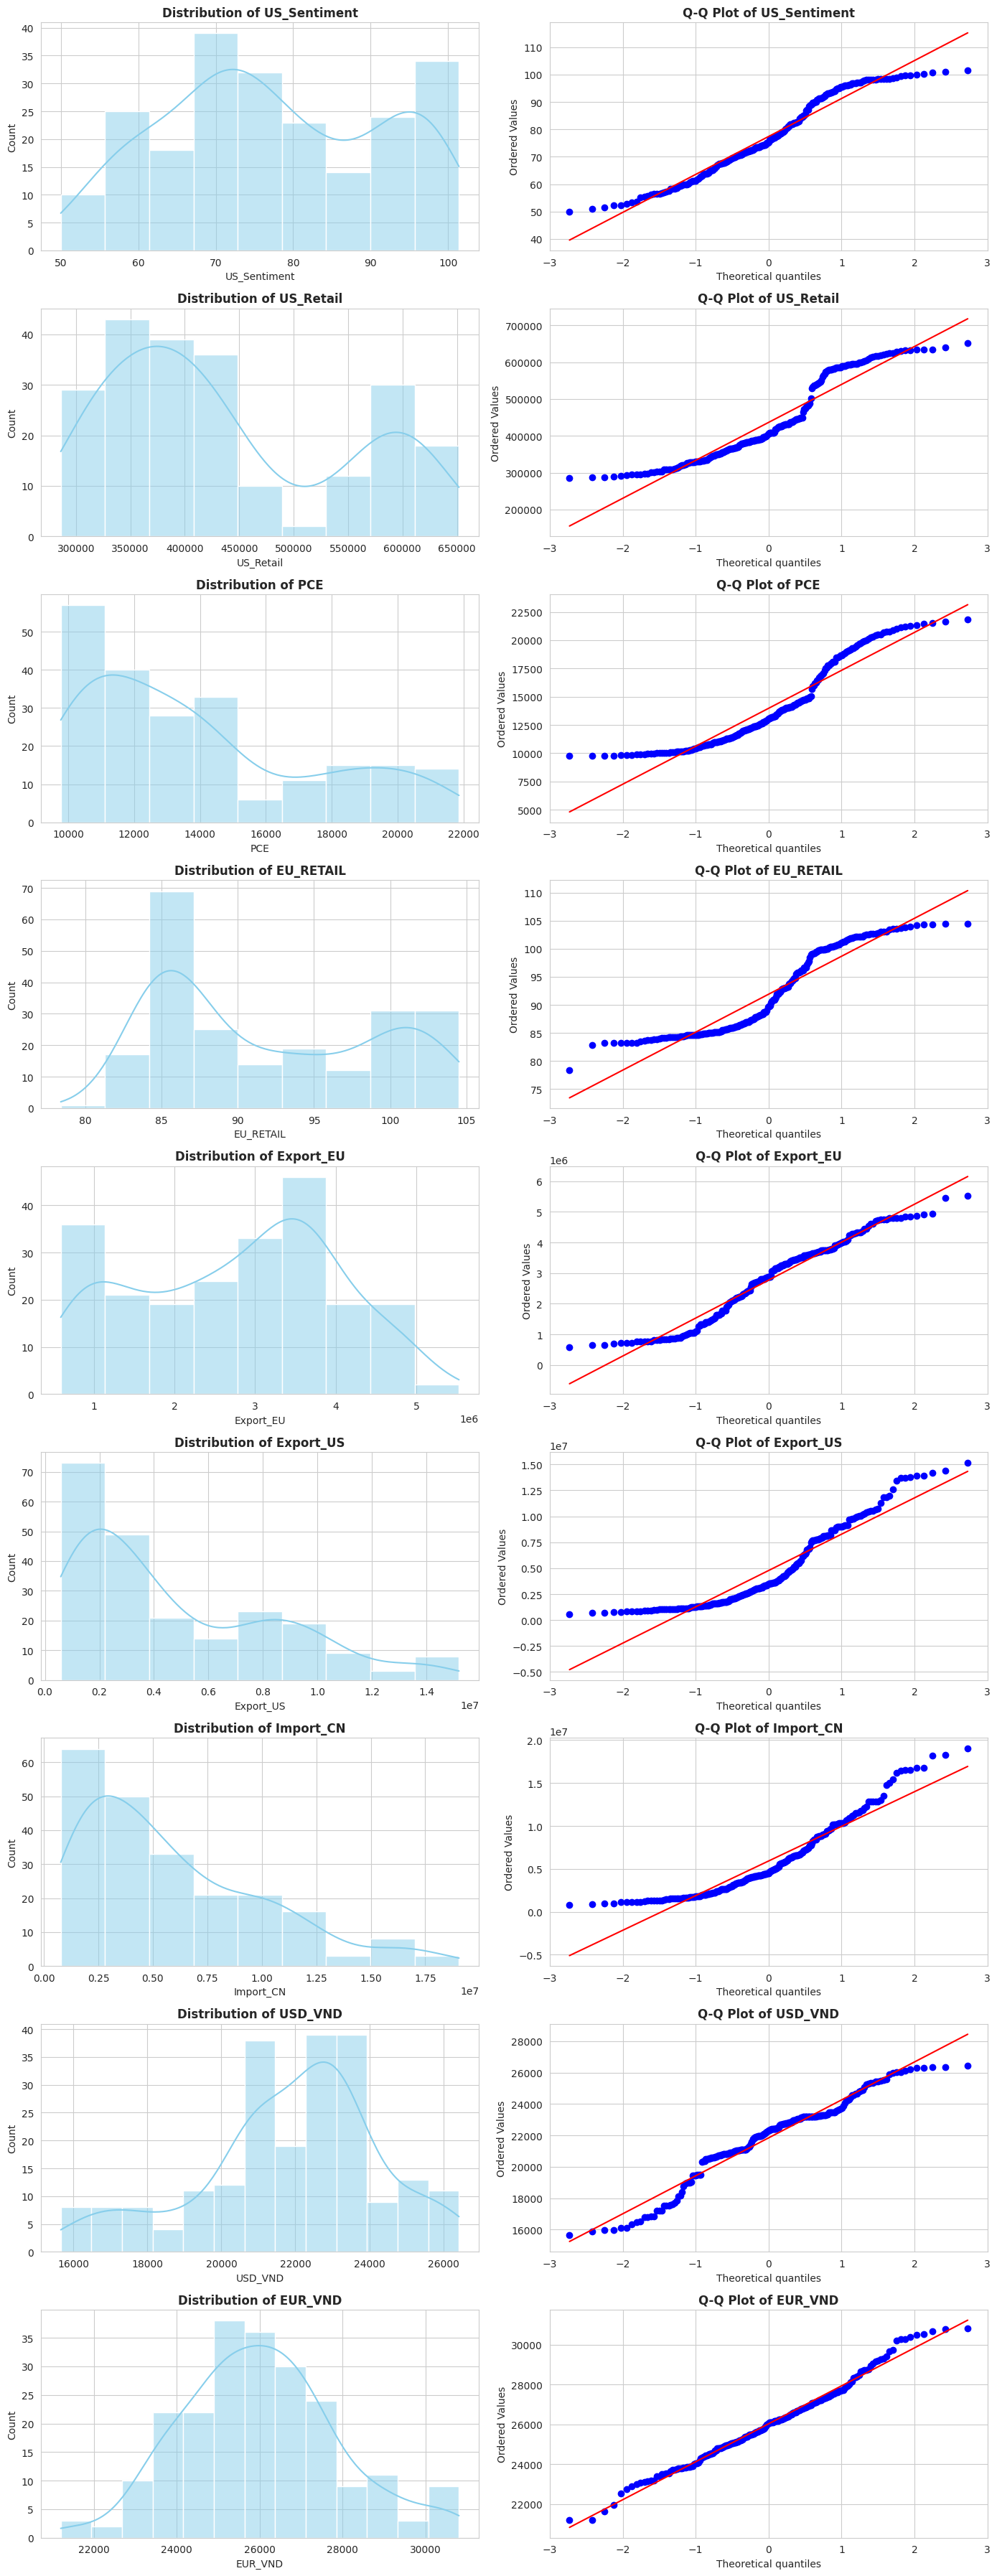


===== CHI TIẾT CÁC ĐIỂM NGOẠI LỆ =====

> Import_CN: Phát hiện 3 điểm ngoại lệ
TIME_PERIOD   Import_CN
 2025-12-01 18255317.38
 2026-01-01 19046886.81
 2026-03-01 18229398.20

> USD_VND: Phát hiện 13 điểm ngoại lệ
TIME_PERIOD  USD_VND
 2008-01-01  15868.0
 2008-02-01  15960.0
 2008-03-01  15654.0
 2008-04-01  16115.0
 2008-05-01  16120.0
 2008-06-01  15986.0
 2008-07-01  16847.0
 2008-08-01  16506.0
 2008-09-01  16324.0
 2008-10-01  16456.0
 2008-11-01  16812.0
 2008-12-01  16812.0
 2009-06-01  16855.0

> EUR_VND: Phát hiện 5 điểm ngoại lệ
TIME_PERIOD  EUR_VND
 2008-11-01  21203.0
 2008-12-01  21206.0
 2025-10-01  30810.0
 2026-01-01  30666.0
 2026-02-01  30766.0


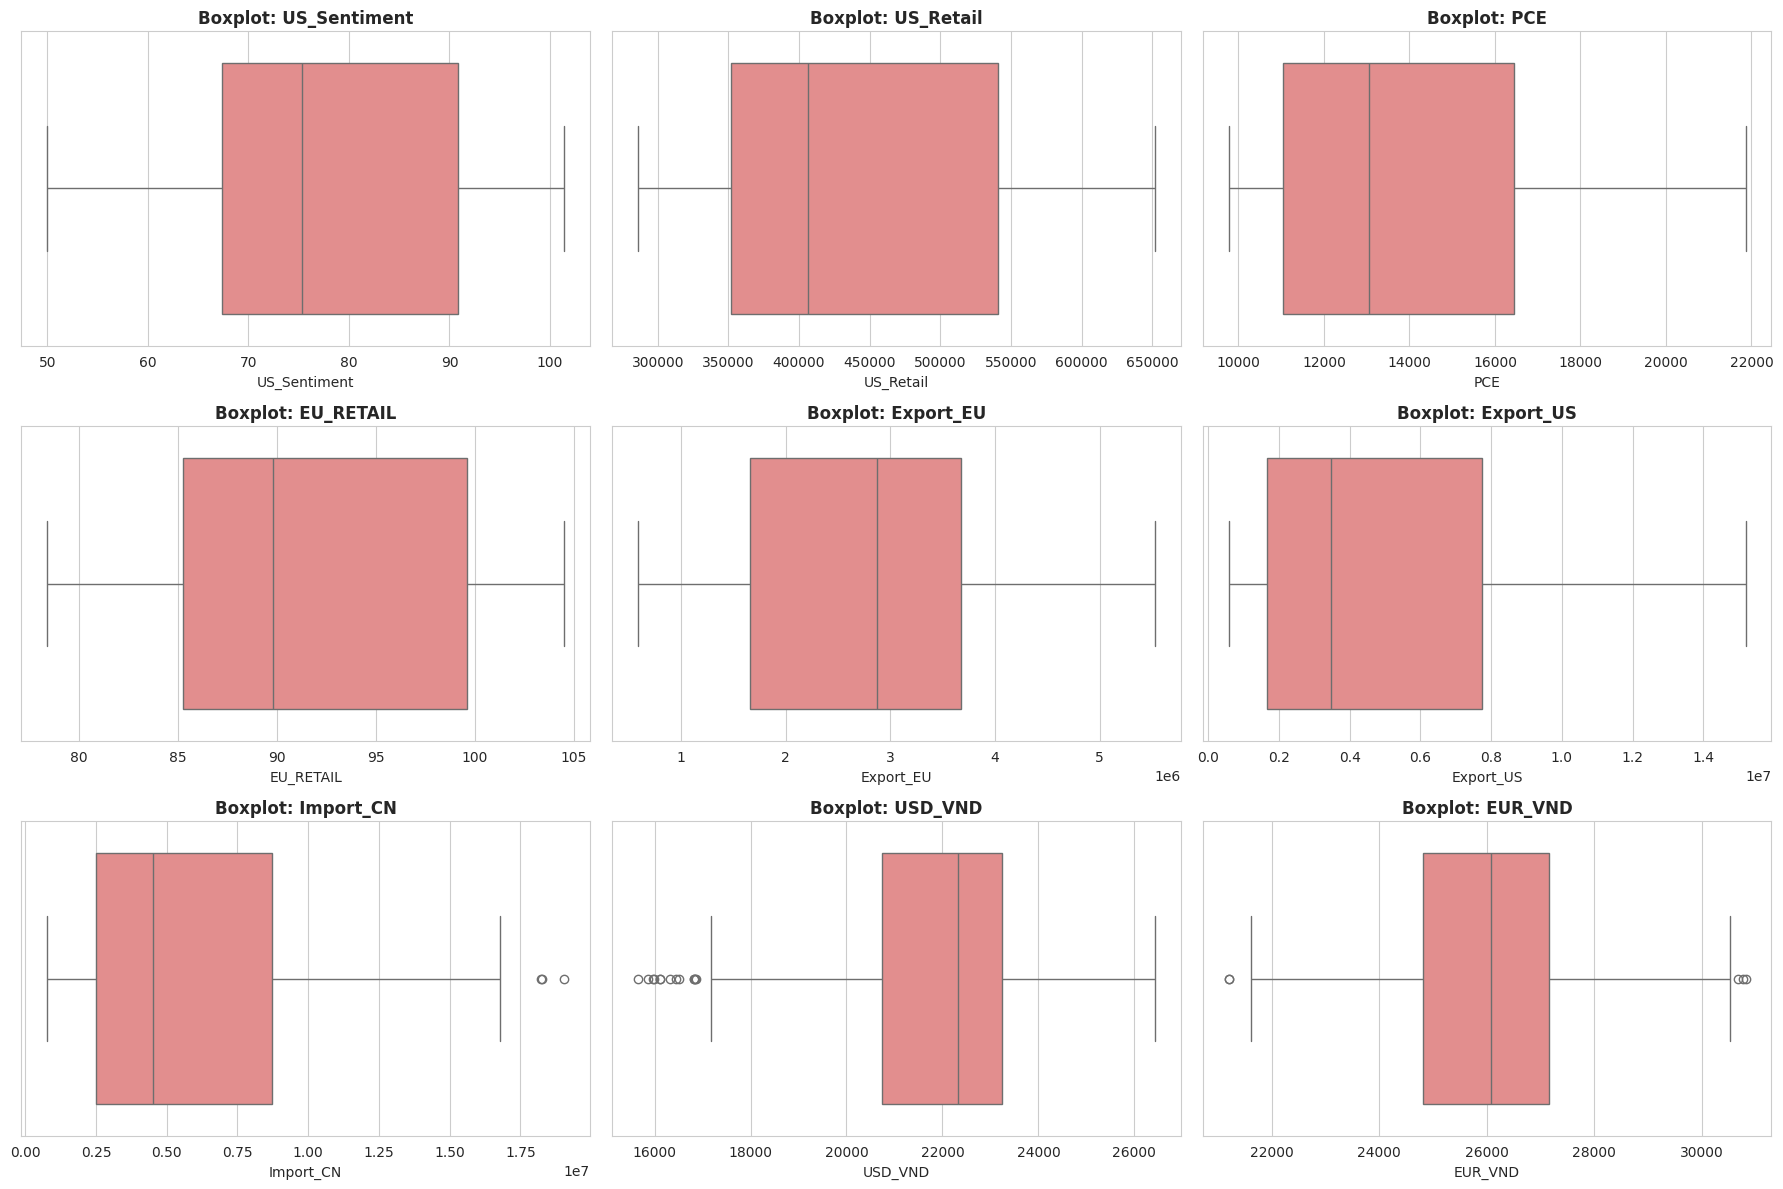

In [ ]:
# HISTOGRAM + KDE + QQ PLOT
fig, axes = plt.subplots(
    nrows=len(cols),
    ncols=2,
    figsize=(14, 4 * len(cols))
)

for i, col in enumerate(cols):

    # Histogram + KDE
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i, 0],
        color='skyblue'
    )

    axes[i, 0].set_title(
        f"Distribution of {col}",
        fontweight='bold'
    )

    # QQ Plot
    stats.probplot(
        df[col],
        dist="norm",
        plot=axes[i, 1]
    )

    axes[i, 1].set_title(
        f"Q-Q Plot of {col}",
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# BOXPLOT + OUTLIERS
n_cols_plot = 3
n_rows_plot = (len(cols) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(
    nrows=n_rows_plot,
    ncols=n_cols_plot,
    figsize=(18, 4 * n_rows_plot)
)

axes = axes.flatten()

print("\n===== CHI TIẾT CÁC ĐIỂM NGOẠI LỆ =====")

for i, col in enumerate(cols):

    # Boxplot
    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color='lightcoral'
    )

    axes[i].set_title(
        f"Boxplot: {col}",
        fontweight='bold'
    )

    # Tính outliers theo IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    # In outliers
    if not outliers.empty:

        print(f"\n> {col}: Phát hiện {len(outliers)} điểm ngoại lệ")

        print(
            outliers[
                ["TIME_PERIOD", col]
            ].to_string(index=False)
        )

# Ẩn subplot thừa
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


**1. Histogram + KDE**

Histogram cho thấy:

- phần lớn biến có dạng phân phối tương đối mượt và liên tục.
- một số biến như: Export_US, Import_CN
có xu hướng lệch phải rõ rệt.

Điều này phù hợp với: skewness dương trong bảng thống kê.

**2. QQ Plot**

QQ Plot cho thấy:

- nhiều biến không nằm hoàn toàn trên đường thẳng chuẩn.
- dữ liệu ở hai đầu phân phối có xu hướng lệch khỏi đường chuẩn.

Đặc biệt: Import_CN, Export_US có độ lệch rõ hơn ở phần đuôi.

=> cho thấy: dữ liệu không hoàn toàn tuân theo phân phối chuẩn.

**3. Boxplot và Outliers**

Import_CN

- Phát hiện:
  3 outliers lớn vào cuối giai đoạn dữ liệu:

>2025-12

>2026-01

>2026-03

=> cho thấy: nhập khẩu từ Trung Quốc tăng mạnh bất thường ở cuối chuỗi thời gian.

USD_VND

- Phát hiện: 13 outliers chủ yếu giai đoạn 2008–2009.

=> cho thấy: tỷ giá USD/VND có biến động mạnh ở đầu chuỗi dữ liệu.

EUR_VND

- Xuất hiện:

>outliers thấp năm 2008

>outliers cao cuối 2025–2026

=> thể hiện: tỷ giá EUR/VND có biến động mạnh theo từng giai đoạn kinh tế.

**1. Giá trị trung bình và trung vị**

Phần lớn các biến có: Mean gần Median

Điều này cho thấy: dữ liệu tương đối cân đối và không bị lệch quá mạnh.

Tuy nhiên:

>Export_US

>Import_CN

có khoảng cách Mean và Median lớn hơn.

Điều này cho thấy: tồn tại một số giá trị rất cao làm kéo trung bình tăng lên.

**2. Độ lệch chuẩn và phương sai**

Các biến thương mại:

>Export_US

>Import_CN

>Export_EU

có: độ lệch chuẩn lớn, phương sai rất cao

=> cho thấy: dữ liệu biến động mạnh theo thời gian.

Trong khi:

>US_Sentiment

>EU_RETAIL

có mức biến động ổn định hơn.

**3. Phân tích Skewness (Độ lệch)**

Mức	Ý nghĩa

- gần 0	đối xứng

- lệch phải (> 0)

- lệch trái (< 0)

Kết quả:

>US_Sentiment (0.05)

>Export_EU (-0.11)

>EUR_VND (0.26)

→ phân phối khá đối xứng.

Các biến lệch phải:

>Export_US (0.89)

>Import_CN (1.01)

=> xuất hiện các giá trị tăng mạnh bất thường.

Đặc biệt:

Import_CN có skewness > 1
→ lệch phải mạnh nhất dataset.

Các biến lệch trái:

>USD_VND (-0.54)

=> tồn tại một số giai đoạn có giá trị thấp bất thường.

**4. Phân tích Kurtosis (Độ nhọn)**
Giá trị	Ý nghĩa
- nhọn, đuôi dày (> 0	)

- bẹt_platykurtic (< 0	)

Phần lớn biến có kurtosis âm:

>US_Sentiment (-1.10)

>EU_RETAIL (-1.38)

>Export_EU (-1.01)

=> phân phối khá bẹt, ít xuất hiện extreme values.

Riêng:

>Import_CN (0.37)

có kurtosis dương nhẹ:
cho thấy dữ liệu có xu hướng xuất hiện một số giá trị cực trị.

### Từ phân phối dữ liệu đến câu hỏi chuỗi thời gian

Các thống kê phân phối cho thấy nhóm biến thương mại như `Export_US`, `Export_EU` và `Import_CN` có mức biến động lớn hơn so với các biến chỉ số như `US_Sentiment` hoặc `EU_RETAIL`. Điều này là hợp lý vì kim ngạch thương mại thường chịu tác động đồng thời từ cầu tiêu dùng, chuỗi cung ứng, tỷ giá và các cú sốc vĩ mô.

Tuy nhiên, phân phối chỉ cho biết dữ liệu “trông như thế nào” về mặt tổng quát. Vì dữ liệu của bài là dữ liệu theo tháng, câu hỏi quan trọng hơn là: **các biến thay đổi như thế nào theo thời gian, có cùng xu hướng với nhau không, và có giai đoạn nào bị bẻ gãy hay không?**

Do đó, phần tiếp theo chuyển từ phân tích phân phối sang phân tích chuỗi thời gian.

### Khám Phá Chuỗi Thời Gian

#### 1. Toàn Chuỗi Thời Gian

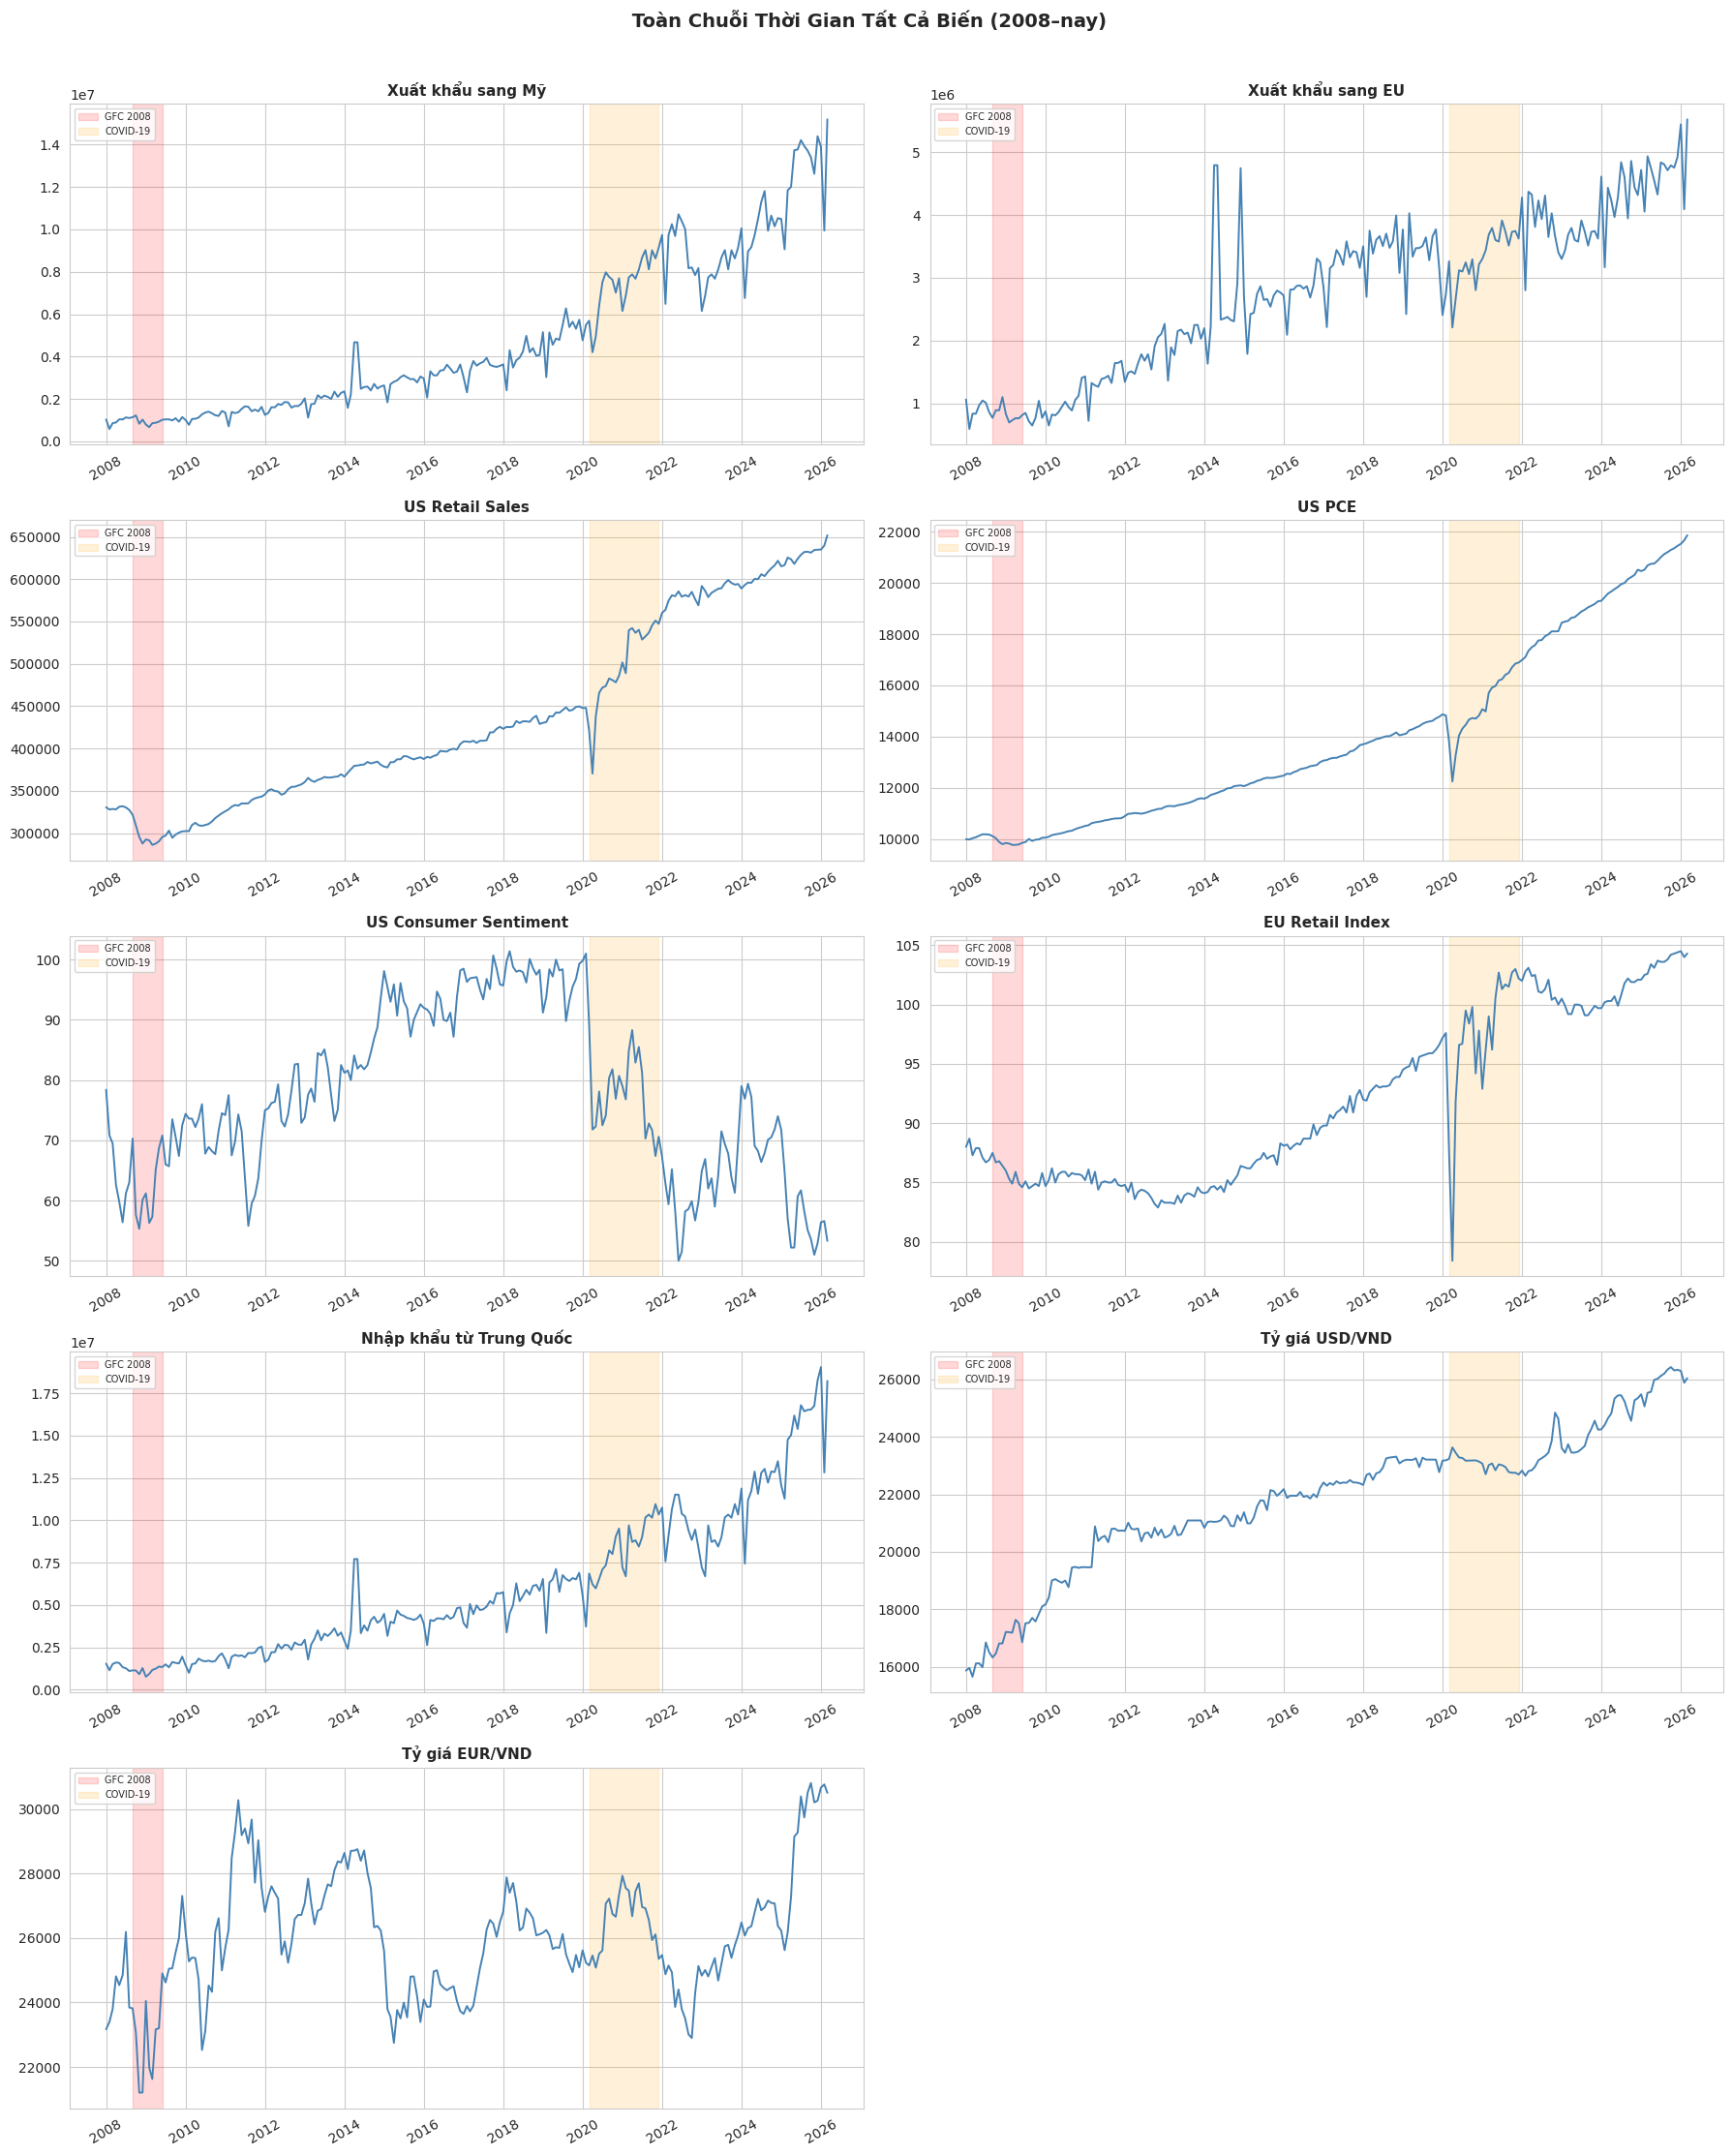

In [ ]:
df['TIME_PERIOD'] = pd.to_datetime(df['TIME_PERIOD'])
df_ts = df.set_index('TIME_PERIOD').copy()

cols_plot = {
    'Export_US'   : 'Xuất khẩu sang Mỹ',
    'Export_EU'   : 'Xuất khẩu sang EU',
    'US_Retail'   : 'US Retail Sales',
    'PCE'         : 'US PCE',
    'US_Sentiment': 'US Consumer Sentiment',
    'EU_RETAIL'   : 'EU Retail Index',
    'Import_CN'   : 'Nhập khẩu từ Trung Quốc',
    'USD_VND'     : 'Tỷ giá USD/VND',
    'EUR_VND'     : 'Tỷ giá EUR/VND',
}

fig, axes = plt.subplots(5, 2, figsize=(18, 22))
axes = axes.flatten()

for ax, (col, title) in zip(axes, cols_plot.items()):
    ax.plot(df_ts.index, df_ts[col], linewidth=1.4, color='steelblue')
    ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-01'),
               alpha=0.15, color='red', label='GFC 2008')
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'),
               alpha=0.15, color='orange', label='COVID-19')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=7, loc='upper left')

axes[-1].set_visible(False)

plt.suptitle(' Toàn Chuỗi Thời Gian Tất Cả Biến (2008–nay)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Đánh giá:**
- Xuất khẩu sang Mỹ không chỉ tăng — mà đang tăng tốc: Trong 18 năm từ 2008 đến 2026, kim ngạch xuất khẩu sang Mỹ tăng từ ~990 triệu lên ~15,2 tỷ USD/tháng — gấp hơn 15 lần. Điều đáng chú ý không phải con số tuyệt đối, mà là hình dạng của sự tăng trưởng: giai đoạn 2008–2019 tăng tuyến tính và chậm, nhưng từ 2020 trở đi đường cong bẻ gãy lên dạng hàm mũ.
- Tiêu dùng Mỹ tăng đều, nhưng xuất khẩu Việt Nam tăng nhanh hơn — có gì đó ngoài tiêu dùng đang xảy ra: US_Retail và PCE tăng gần như tuyến tính, ổn định, không bị cú sốc nào làm gián đoạn lâu dài. Nhưng Export_US lại tăng nhanh hơn và vượt xa tốc độ đó từ 2020. Khoảng cách ngày càng rộng này là tín hiệu rõ ràng: Việt Nam không chỉ đang hưởng lợi từ tiêu dùng Mỹ tăng mà còn đang giành thêm thị phần trong rổ hàng hóa người Mỹ mua — một phần do chiến tranh thương mại Mỹ–Trung (2018) đẩy đơn hàng sang Việt Nam.
- Người Mỹ ngày càng bi quan — nhưng vẫn mua hàng Việt Nam nhiều hơn: US Consumer Sentiment là biến duy nhất trong toàn bộ dữ liệu đi ngược chiều với xuất khẩu Việt Nam trong dài hạn: đạt đỉnh ~100 năm 2018, rồi giảm liên tục xuống còn ~55 vào 2026. Trong cùng giai đoạn đó, Export_US tăng gấp đôi. Nghịch lý này đặt ra câu hỏi cốt lõi: tâm lý tiêu dùng có thực sự phản ánh hành vi mua hàng không, hay chỉ phản ánh lo ngại lạm phát trong khi chi tiêu thực tế vẫn tiếp tục?




**Insight chuyển tiếp**

Biểu đồ chuỗi thời gian cho thấy xuất khẩu Việt Nam, đặc biệt sang Mỹ, tăng nhanh hơn nhiều so với các chỉ báo tiêu dùng truyền thống. Đây là tín hiệu quan trọng: nếu chỉ nhìn sức mua của người tiêu dùng, ta chưa giải thích hết tốc độ tăng của xuất khẩu.

Vì vậy, bài cần tiếp tục tách chuỗi thành các thành phần **xu hướng dài hạn, mùa vụ và nhiễu ngắn hạn**. Mục tiêu là xác định liệu mức tăng này chủ yếu đến từ xu hướng bền vững, dao động mùa vụ, hay một số cú sốc bất thường trong từng giai đoạn.

#### 2. Phân Rã Chuỗi (STL Decomposition)

**2a**: Bảng tóm tắt Trend Strength & Seasonal Strength toàn bộ biến.  

In [ ]:
from statsmodels.tsa.seasonal import STL

all_cols = ['Export_US', 'Export_EU', 'US_Retail', 'PCE',
            'US_Sentiment', 'EU_RETAIL', 'Import_CN', 'USD_VND', 'EUR_VND']

print("BẢNG TÓM TẮT STL – TREND & SEASONAL STRENGTH")
print("=" * 62)
print(f"{'Biến':<18} {'Trend Strength':>16} {'Seasonal Strength':>18}  Nhận xét")
print("-" * 62)

stl_results = {}
for col in all_cols:
    series = df_ts[col].dropna()
    stl = STL(series, period=12, robust=True)
    res = stl.fit()
    stl_results[col] = res

    vr = res.resid.var()
    vt = res.trend.var()
    vs = res.seasonal.var()
    ts = max(0, 1 - vr / (vt + vr))
    ss = max(0, 1 - vr / (vs + vr))

    # Trend note
    if ts >= 0.7:
        trend_note = 'Trend mạnh'
    elif ts >= 0.4:
        trend_note = 'Trend trung bình'
    else:
        trend_note = 'Trend yếu'

    # Seasonal note
    if ss >= 0.6:
        season_note = 'Season mạnh'
    elif ss >= 0.3:
        season_note = 'Season trung bình'
    else:
        season_note = 'Season yếu'

    note = f'{trend_note} / {season_note}'
    print(f"{col:<18} {ts:>16.3f} {ss:>18.3f}  {note}")



BẢNG TÓM TẮT STL – TREND & SEASONAL STRENGTH
Biến                 Trend Strength  Seasonal Strength  Nhận xét
--------------------------------------------------------------
Export_US                     0.976              0.507  Trend mạnh / Season trung bình
Export_EU                     0.916              0.290  Trend mạnh / Season yếu
US_Retail                     0.992              0.079  Trend mạnh / Season yếu
PCE                           0.994              0.035  Trend mạnh / Season yếu
US_Sentiment                  0.878              0.288  Trend mạnh / Season yếu
EU_RETAIL                     0.924              0.531  Trend mạnh / Season trung bình
Import_CN                     0.970              0.553  Trend mạnh / Season trung bình
USD_VND                       0.991              0.235  Trend mạnh / Season yếu
EUR_VND                       0.705              0.183  Trend mạnh / Season yếu


**2b**: Vẽ STL chi tiết cho 2 cặp biến cốt lõi của đề tài:  
- `US_Retail` ↔ `Export_US`  
- `EU_RETAIL` ↔ `Export_EU`

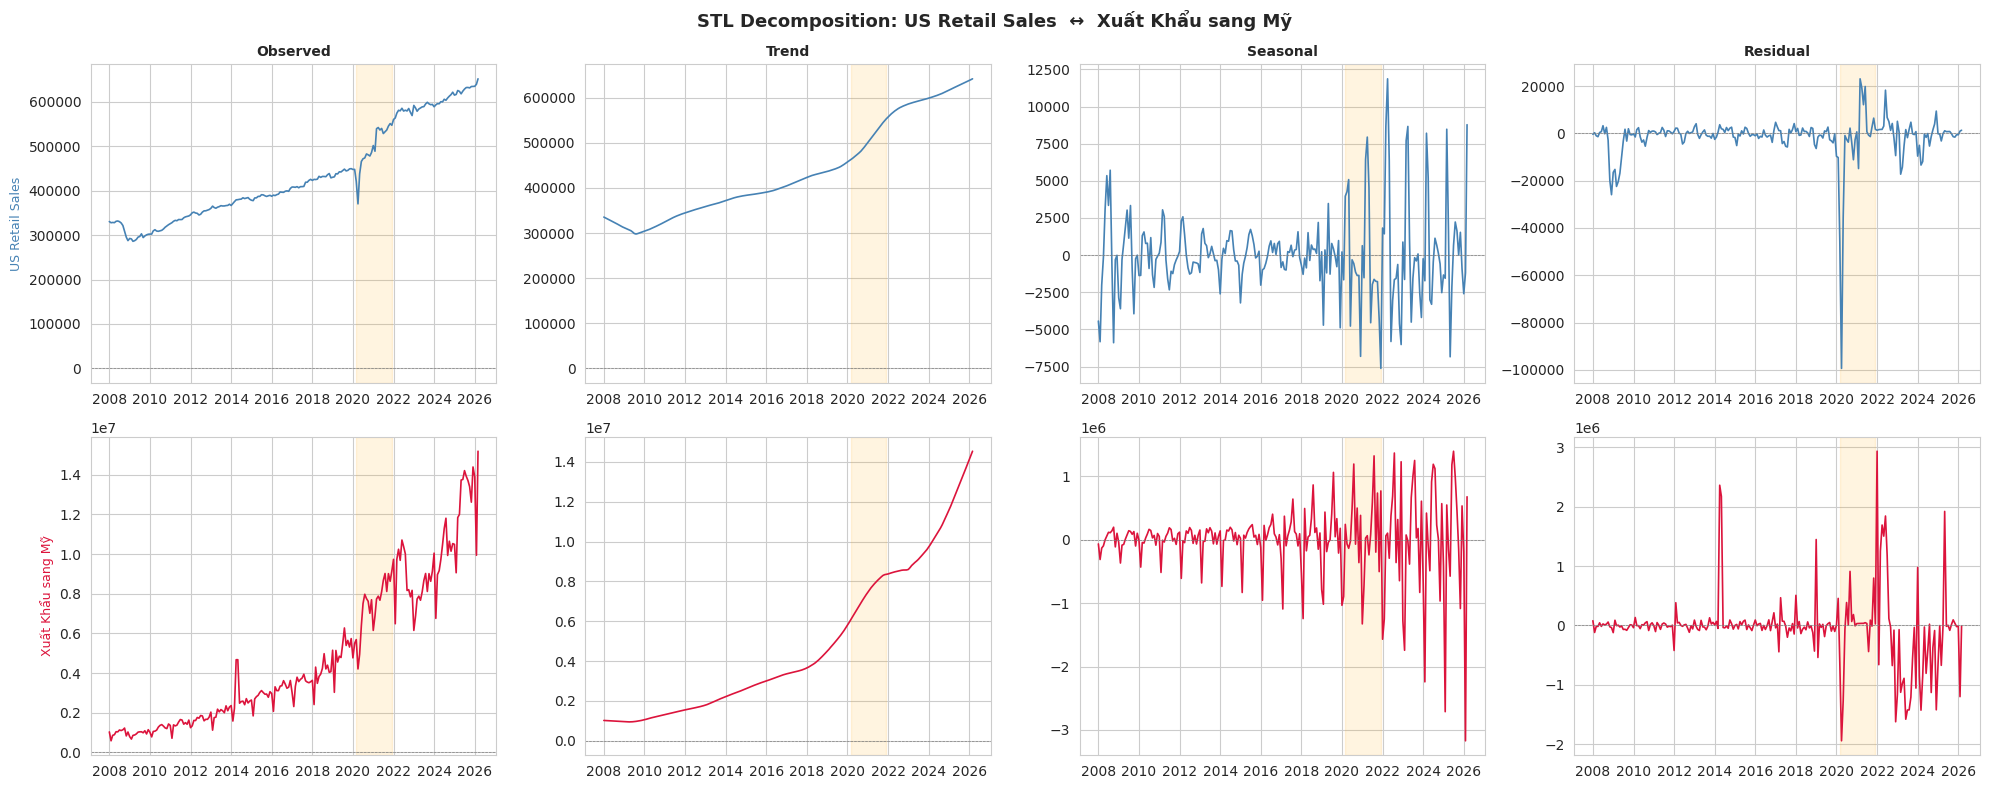

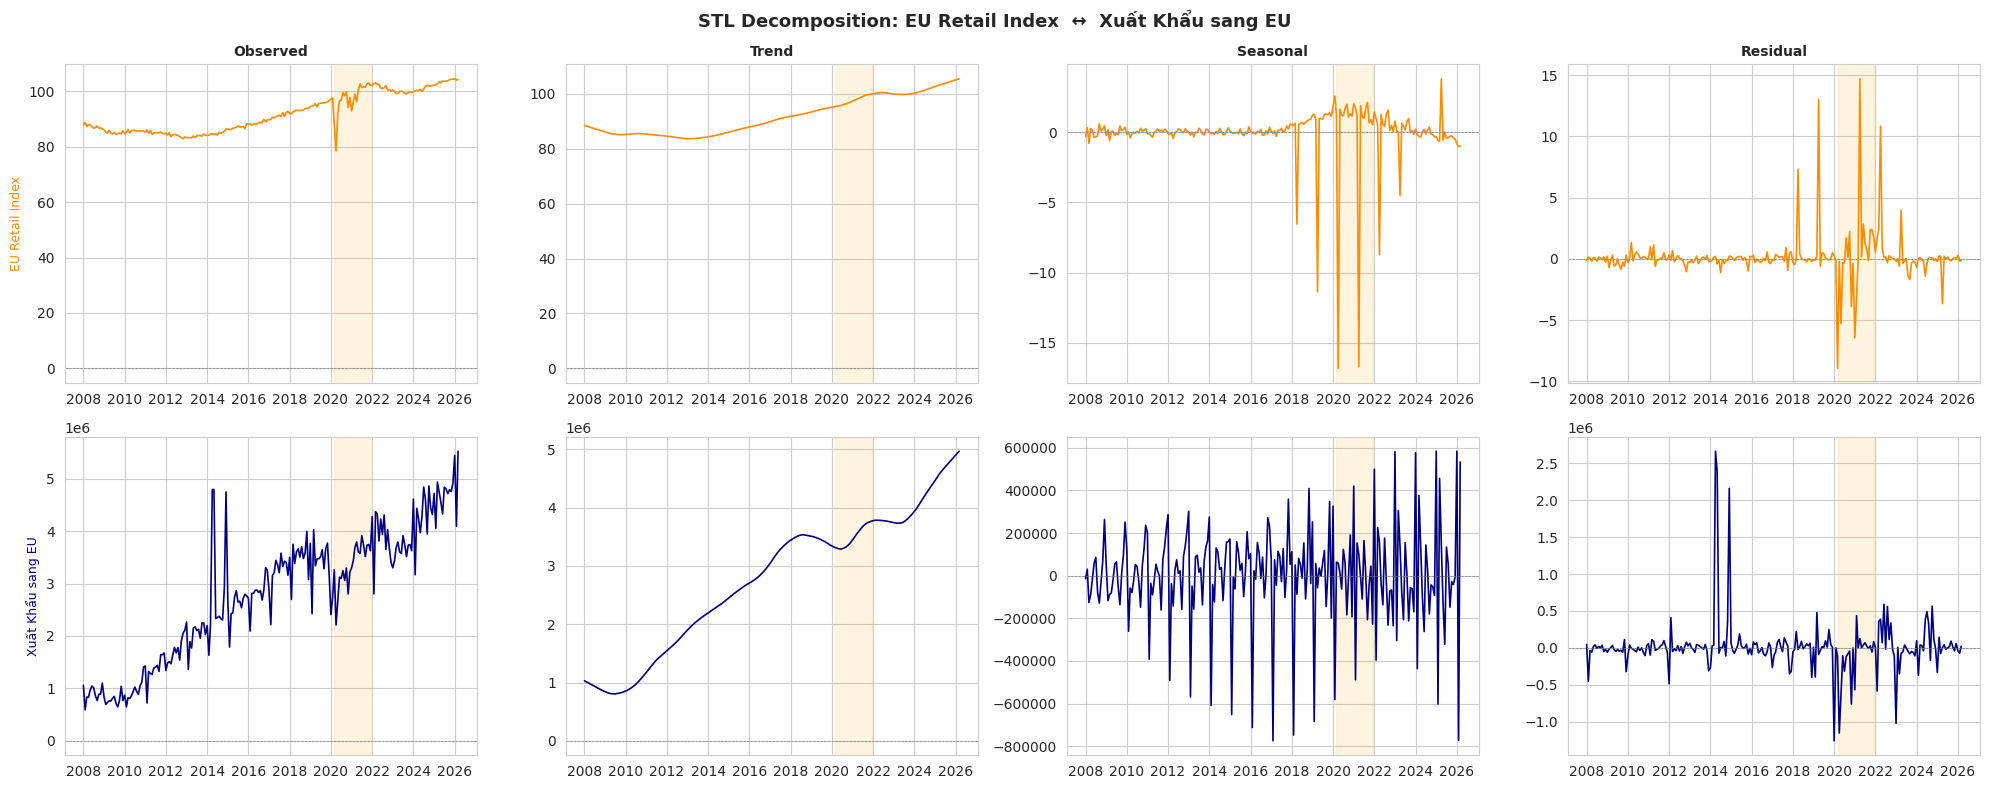

In [ ]:
core_pairs = [
    ('US_Retail', 'Export_US', 'US Retail Sales', 'Xuất Khẩu sang Mỹ', 'steelblue', 'crimson'),
    ('EU_RETAIL', 'Export_EU', 'EU Retail Index',  'Xuất Khẩu sang EU',  'darkorange', 'navy'),
]

for c_consume, c_export, lbl_c, lbl_e, col_c, col_e in core_pairs:
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    labels = ['Observed', 'Trend', 'Seasonal', 'Residual']

    for row, (col, color, lbl) in enumerate([
        (c_consume, col_c, lbl_c),
        (c_export,  col_e, lbl_e),
    ]):
        res = stl_results[col]
        components = [df_ts[col].dropna(), res.trend, res.seasonal, res.resid]
        for j, (comp, lbl_j) in enumerate(zip(components, labels)):
            ax = axes[row][j]
            ax.plot(comp.index, comp.values, linewidth=1.2, color=color)
            ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'),
                       alpha=0.12, color='orange')
            ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
            if row == 0:
                ax.set_title(lbl_j, fontsize=10, fontweight='bold')
            if j == 0:
                ax.set_ylabel(lbl, fontsize=9, color=color)

    plt.suptitle(f'STL Decomposition: {lbl_c}  ↔  {lbl_e}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()



**1. Thành phần Observed (Dữ liệu gốc)**

Kết quả cho thấy cả US Retail Sales, EU Retail Index và kim ngạch xuất khẩu của Việt Nam sang Mỹ và EU đều có xu hướng tăng theo thời gian.
- Giai đoạn 2008–2009 xuất hiện sự suy giảm do ảnh hưởng của khủng hoảng tài chính toàn cầu.
- Trong giai đoạn COVID-19, cả tiêu dùng và xuất khẩu đều xuất hiện các biến động mạnh.
- Sau COVID, các chuỗi phục hồi nhanh và tiếp tục tăng mạnh, đặc biệt là xuất khẩu sang Mỹ.

Điều này phản ánh: Nhu cầu tiêu dùng tại Mỹ và EU phục hồi sau đại dịch, đồng thời kéo theo nhu cầu nhập khẩu hàng hóa từ Việt Nam tăng lên.

**2. Thành phần Trend (Xu hướng dài hạn)**

Các biểu đồ trend cho thấy: Tiêu dùng tại Mỹ và EU đều có xu hướng tăng dài hạn, xuất khẩu Việt Nam sang hai thị trường này cũng tăng liên tục theo thời gian. Đặc biệt sau năm 2020, trend của Export_US tăng rất mạnh, Export_EU cũng duy trì xu hướng tăng ổn định dù có chững nhẹ trong thời kỳ COVID.

Điều này cho thấy sự phục hồi và mở rộng nhu cầu tiêu dùng tại các nền kinh tế lớn có tác động tích cực đến xuất khẩu Việt Nam. Mỹ hiện là thị trường có tốc độ tăng trưởng xuất khẩu mạnh hơn EU.

Kết quả cũng phản ánh mối quan hệ cùng chiều giữa tiêu dùng và xuất khẩu:

**Consumption↑ ⇒ Vietnam Export↑**

**3. Thành phần Seasonal (Mùa vụ)**

Kết quả STL decomposition và biểu đồ seasonal cho thấy các chuỗi thời gian đều tồn tại thành phần seasonal, tuy nhiên mức độ ảnh hưởng của seasonality nhìn chung thấp hơn đáng kể so với trend.

Bảng Trend Strength và Seasonal Strength: hầu hết các biến có Trend Strength rất cao (> 0.9), trong khi Seasonal Strength chủ yếu ở mức thấp đến trung bình. Nên biến động của các chuỗi thời gian chủ yếu được dẫn dắt bởi xu hướng dài hạn,
thay vì các chu kỳ mùa vụ lặp lại hàng năm. Phản ánh tiêu dùng tại Mỹ tăng chủ yếu theo xu hướng kinh tế dài hạn, yếu tố mùa vụ chỉ đóng vai trò nhỏ.

**4. Thành phần Residual (Nhiễu)**

Residual phản ánh các biến động bất thường ngoài trend và seasonality.

Kết quả: Trước COVID, residual tương đối ổn định. Trong và sau COVID xuất hiện nhiều spike lớn ở cả retail sales và xuất khẩu.

Suy ra:
- Đại dịch COVID-19 tạo ra cú sốc lớn đối với chuỗi cung ứng và thương mại toàn cầu
- Xuất khẩu Việt Nam không chỉ chịu ảnh hưởng từ tiêu dùng mà còn từ: Logistics,chi phí vận chuyển, lạm phát, tỷ giá, chính sách thương mại, gián đoạn chuỗi cung ứng toàn cầu,....

Residual của Export_US biến động mạnh hơn Export_EU, phản ánh thị trường Mỹ có độ nhạy cao hơn đối với các biến động kinh tế và thương mại.

#### Kết luận sau STL Decomposition

STL cho thấy phần lớn các chuỗi kinh tế trong bài có **trend dài hạn rõ rệt**. Điều này có hai ý nghĩa quan trọng:

1. Xuất khẩu Việt Nam sang Mỹ và EU có xu hướng tăng thực sự trong dài hạn, không chỉ là dao động ngắn hạn.
2. Vì nhiều biến cùng tăng theo thời gian, nếu hồi quy trực tiếp trên dữ liệu gốc thì rất dễ tạo ra tương quan cao nhưng chưa chắc phản ánh quan hệ kinh tế thật.

Nói cách khác, STL giúp củng cố câu chuyện tăng trưởng, nhưng đồng thời cảnh báo rằng dữ liệu cần được kiểm tra tính dừng trước khi đưa vào mô hình định lượng.

#### 3. Theo Từng Giai Đoạn

-  Trước Covid
-  Trong Covid
-  Sau Covid

/tmp/ipykernel_56331/2982628581.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True,
/tmp/ipykernel_56331/2982628581.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True,


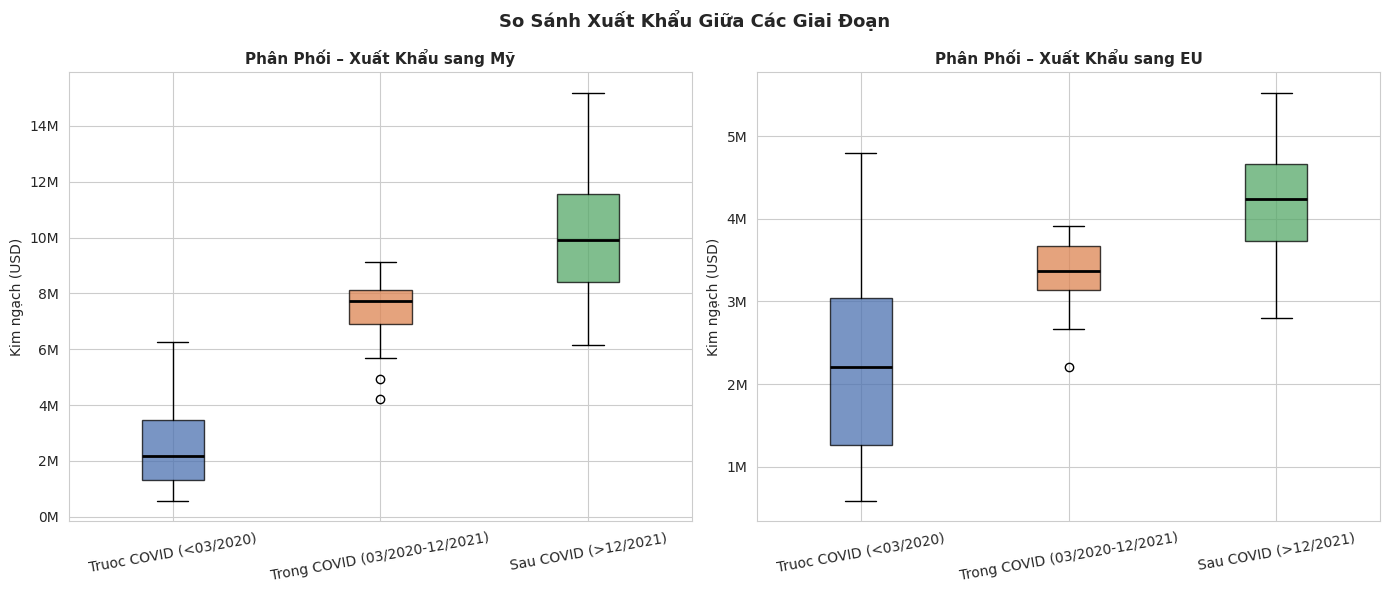

Giai đoạn                             Export_US TB   Export_EU TB  n (tháng)
------------------------------------------------------------------------------
Truoc COVID (<03/2020)                   2,494,285      2,191,015        146
Trong COVID (03/2020-12/2021)            7,447,073      3,348,350         22
Sau COVID (>12/2021)                    10,159,255      4,185,709         51


In [ ]:
pre_covid    = df[df['TIME_PERIOD'] < '2020-03-01'].copy()
during_covid = df[(df['TIME_PERIOD'] >= '2020-03-01') &
                         (df['TIME_PERIOD'] <= '2021-12-31')].copy()
post_covid   = df[df['TIME_PERIOD'] > '2021-12-31'].copy()

phases = {
    'Truoc COVID (<03/2020)'        : pre_covid,
    'Trong COVID (03/2020-12/2021)' : during_covid,
    'Sau COVID (>12/2021)'          : post_covid,
}
colors_box = ['#4C72B0', '#DD8452', '#55A868']

# Box plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, title in zip(axes,
    ['Export_US', 'Export_EU'],
    ['Xuất Khẩu sang Mỹ', 'Xuất Khẩu sang EU']):

    data_to_plot = [df[col].dropna().values for df in phases.values()]
    bp = ax.boxplot(data_to_plot, patch_artist=True,
                    labels=list(phases.keys()),
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(f'Phân Phối – {title}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Kim ngạch (USD)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('So Sánh Xuất Khẩu Giữa Các Giai Đoạn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Bảng tóm tắt
print(f"{'Giai đoạn':<35} {'Export_US TB':>14} {'Export_EU TB':>14} {'n (tháng)':>10}")
print("-" * 78)
for name, df_sub in phases.items():
    print(f"{name:<35} "
          f"{df_sub['Export_US'].mean():>14,.0f} "
          f"{df_sub['Export_EU'].mean():>14,.0f} "
          f"{len(df_sub):>10}")


Đánh giá:
- COVID không đánh sập xuất khẩu Việt Nam sang Mỹ — nó tăng gấp 3 lần: Trong giai đoạn COVID (03/2020–12/2021), trung bình xuất khẩu sang Mỹ không giảm mà tăng từ ~2,5 tỷ lên ~7,4 tỷ USD/tháng. Cơ chế: gói stimulus khổng lồ của Mỹ bơm tiền trực tiếp vào tay người dân, trong khi họ bị kẹt ở nhà không thể chi tiêu cho dịch vụ (nhà hàng, du lịch, giải trí) → toàn bộ chi tiêu đổ vào hàng hóa → hàng Việt Nam với lợi thế giá và nguồn cung ổn định hưởng lợi trực tiếp. COVID, nghịch lý thay, lại là cú hích lớn nhất cho xuất khẩu Việt Nam trong lịch sử.
- Thị trường EU ổn định nhưng không bùng nổ: Export_EU tăng +53% trong COVID và +25% sau COVID — nhịp đều đặn, box plot hẹp, ít outlier. Không có sự bùng nổ đột biến như thị trường Mỹ, nhưng cũng không có rủi ro sụt giảm mạnh. Mỹ là thị trường tăng trưởng cao-rủi ro cao; EU là thị trường tăng trưởng vừa-rủi ro thấp. Chiến lược xuất khẩu tối ưu cần khai thác cả hai vai trò này song song.
- Việt Nam đang đặt cược ngày càng nhiều vào một thị trường duy nhất
Trước COVID, xuất khẩu sang Mỹ và EU gần như ngang nhau (~2,5 tỷ và ~2,2 tỷ USD/tháng). Sau COVID, khoảng cách doãng ra đáng kể: Mỹ ~10,2 tỷ trong khi EU chỉ ~4,2 tỷ USD/tháng — Mỹ hiện chiếm tỷ trọng gấp 2,4 lần EU. Sự tập trung vào một thị trường mang lại tăng trưởng nhanh, nhưng cũng tạo ra rủi ro lớn: bất kỳ cú sốc nào từ kinh tế Mỹ — suy thoái, leo thang thuế quan, thay đổi chính sách thương mại — đều có thể tác động mạnh và trực tiếp lên xuất khẩu Việt Nam.

**Vì sao cần chia trước - trong - sau COVID?**

COVID là một cú sốc đặc biệt vì nó tác động đồng thời lên cả hai phía của thương mại quốc tế:

- Phía cầu: người tiêu dùng thay đổi hành vi chi tiêu, chuyển mạnh sang hàng hóa thay vì dịch vụ.
- Phía cung: logistics, sản xuất và chuỗi cung ứng toàn cầu bị gián đoạn.
- Phía chính sách: các gói kích thích, lạm phát và biến động tỷ giá làm thay đổi môi trường thương mại.

Do đó, nếu chỉ dùng một mô hình cho toàn bộ giai đoạn 2008-2026, ta có thể bỏ qua sự thật rằng **cùng một biến có thể tác động khác nhau ở từng giai đoạn**. Đây là lý do các phần sau sử dụng Rolling OLS và Chow Test để kiểm tra tính ổn định của mối quan hệ.

### Kiểm Tra Độ Trễ

## ARDL + FFNN: Chọn tổ hợp lag tối ưu

Phần này được chèn từ `DA_Prj1_ARDL_FFNN_OG.ipynb` và giữ nguyên logic chính: ARDL đơn biến lọc top lag ứng viên cho từng biến, sau đó FFNN grid search chọn tổ hợp lag riêng tốt nhất theo validation RMSE.

Kết quả quan trọng của phần này là `comparison`, `final_summary` và `best_lag_map_by_market`, được dùng lại từ block **Rolling OLS** trở về sau.


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

from ardl_ffnn_model import ARDLFFNNModel, ardl_diagnostics, build_lagged_design

pd.set_option('display.float_format', '{:,.4f}'.format)


## 1. Đọc dữ liệu và cấu hình biến

Hai thị trường được mô hình hóa riêng:

- US: `Export_US` theo `PCE`, `US_Retail`, `US_Sentiment`, `USD_VND`, `Import_CN`.
- EU: `Export_EU` theo `EU_RETAIL`, `EUR_VND`, `Import_CN`.

Mỗi mô hình luôn giữ thêm `target_lag1` và `target_lag12` để kiểm soát quán tính ngắn hạn và mùa vụ năm.

In [ ]:
local_path = Path('df_final.csv')

markets = {
    'US': {
        'target': 'Export_US',
        'variables': ['PCE', 'US_Retail', 'US_Sentiment', 'USD_VND', 'Import_CN'],
        'lag_candidates': range(0, 7)  # lag riêng được phép xét 0→6; lag chung sẽ tự loại lag 0
    },
    'EU': {
        'target': 'Export_EU',
        'variables': ['EU_RETAIL', 'EUR_VND', 'Import_CN'],
        'lag_candidates': range(0, 7)  # lag riêng được phép xét 0→6; lag chung sẽ tự loại lag 0
    }
}

ardl_ffnn = ARDLFFNNModel(data_path=local_path, markets=markets)
df, df_model, log_df = ardl_ffnn.load_data()
model_cols = ardl_ffnn.model_cols

print('Số quan sát:', len(log_df))
print('Thời gian:', log_df.index.min().strftime('%Y-%m'), 'đến', log_df.index.max().strftime('%Y-%m'))
display(df_model[model_cols].describe().T[['mean', 'std', 'min', 'max']].round(3))


## 2. Kiểm định tính dừng và tạo dữ liệu mô hình

Notebook dùng ADF và KPSS theo cùng một quy tắc thực hành:

- ADF có H0 là chuỗi không dừng, nên cần `ADF p-value < 0.05`.
- KPSS có H0 là chuỗi dừng, nên cần `KPSS p-value > 0.05`.

Biến nào không đạt điều kiện dừng ở log-level sẽ được chuyển sang sai phân log bậc 1 trước khi đưa vào ARDL/FFNN. `log_df` gốc vẫn được giữ lại để quy đổi dự báo về level khi tính RMSE/MAE/MAPE.


In [ ]:
stationarity_screen = ardl_ffnn.run_stationarity_screen()
model_df = ardl_ffnn.model_df
transform_info = ardl_ffnn.transform_info

print('Biến dùng sai phân log bậc 1:', [k for k, v in transform_info.items() if v == 'diff1'])
print('Số quan sát sau xử lý tính dừng:', len(model_df))
display(stationarity_screen.round(4))


## 3. Hàm tạo lag, chia tập và tính metric

Split theo thời gian: 70% train, 15% validation, 15% test. Validation dùng để chọn lag/mô hình; test chỉ dùng ở bước so sánh cuối.

**Lưu ý:** Lag riêng vẫn được phép dùng lag 0 nếu ARDL/FFNN chọn được. Riêng phương án **lag chung** sẽ loại lag 0 để tránh baseline dùng toàn bộ biến cùng kỳ và thắng nhờ thông tin đồng thời.


In [ ]:
# Hàm build_lagged_design đã được tách sang module ardl_ffnn_model.py
# và được import ở đầu phần ARDL + FFNN.


## 4. ARDL đơn biến: tìm top lag cho từng biến

Notebook dùng **ARDL đơn biến** để lấy top 3 lag ứng viên cho từng biến giải thích. Với mỗi biến `X`, mô hình được fit theo dạng:

```text
Export_t ~ Export_t-1 + Export_t-12 + X_t-k
```

Trong đó `k` chạy qua các lag ứng viên từ 0 đến 10 tháng. Lag 0 được giữ lại cho **lag riêng** vì một số biến, đặc biệt biến chuỗi cung ứng như `Import_CN`, có thể có quan hệ đồng thời với xuất khẩu. Sau đó, FFNN sẽ thử toàn bộ tổ hợp được tạo từ top 3 lag của từng biến.

Cách này giúp giữ đúng mục tiêu chính: tìm **độ trễ riêng cho từng feature**, rồi kiểm chứng bằng FFNN so với phương án dùng **một lag chung cho tất cả biến**. Riêng phần lag chung sẽ không dùng lag 0.


In [ ]:
ardl_lag_tables, top_lags_by_market = ardl_ffnn.select_ardl_top_lags(top_n=3)

for market in markets:
    table = ardl_lag_tables[market]
    top_lags = top_lags_by_market[market]

    print(f'===== {market}: Top 3 lag từng biến theo ARDL đơn biến AIC (lag riêng 0→6) =====')
    display(table.groupby('variable').head(3).round(4))
    print(top_lags)


## 5. FFNN grid search trên tổ hợp lag riêng

FFNN nhận input gồm `target_lag1`, `target_lag12` và các biến giải thích tại lag được chọn.

Phần này chỉ chạy một nhóm tổ hợp lag riêng:

- `Lag riêng - ARDL top3 + FFNN grid`: toàn bộ tổ hợp từ top 3 lag của từng biến theo ARDL đơn biến.

Tiêu chí chọn mô hình FFNN là validation RMSE; test chỉ dùng để đọc năng lực dự báo ngoài mẫu.

In [ ]:
ffnn_lag_search_tables, best_separate_lag_rows = ardl_ffnn.run_separate_lag_ffnn_search()

for market in markets:
    table = ffnn_lag_search_tables[market]
    n_lag_maps = np.prod([len(v) for v in top_lags_by_market[market].values()])

    print(f'{market}: số tổ hợp lag riêng cần thử = {n_lag_maps}')
    print(f'===== {market}: Top 5 FFNN lag riêng theo validation RMSE =====')
    display(table.head(5).round(4))


## 6. So sánh với phương án dùng chung một lag

Phương án lag chung cũng được chọn bằng FFNN grid search. Điểm khác biệt duy nhất là mọi biến giải thích bị ràng buộc dùng cùng một lag `k`.

Để so sánh không bị lệch do thông tin cùng kỳ, **lag chung chỉ xét `k = 1 → 10`**. Trong khi đó, **lag riêng vẫn giữ các lag được ARDL/FFNN chọn**, kể cả lag 0 nếu có.


In [ ]:
common_lag_search_tables, best_common_lag_rows = ardl_ffnn.run_common_lag_ffnn_search()

for market in markets:
    table = common_lag_search_tables[market]

    print(f'===== {market}: Top 10 FFNN lag chung theo validation RMSE=====')
    display(table.head(10).round(4))


## 7. Bảng kết quả so sánh cuối cùng

Bảng này có 2 tầng:

1. `comparison`: hiển thị mô hình tốt nhất được chọn theo validation RMSE cho từng nhóm.
2. `final_summary`: so sánh trực tiếp **lag riêng** với **lag chung** trên test set.

Cách đọc phần trăm cải thiện:

- Giá trị dương nghĩa là **lag riêng tốt hơn lag chung**.
- Giá trị âm nghĩa là **lag chung tốt hơn lag riêng**.

Lưu ý: validation dùng để chọn mô hình; test dùng để đánh giá năng lực dự báo ngoài mẫu.

In [ ]:
comparison, final_summary = ardl_ffnn.build_comparison()

print('===== Bảng kết quả tốt nhất theo từng nhóm model =====')
display(comparison.round(4))

print('===== So sánh trực tiếp: Lag riêng ARDL top3 + FFNN grid vs Lag chung FFNN grid =====')
display(final_summary.round(4))


### Tổ hợp lag được chọn để dùng cho các phân tích sau

Sau khi so sánh lag riêng với lag chung, notebook lấy mô hình `Lag riêng - ARDL top3 + FFNN grid` làm nguồn lag chính cho Rolling OLS, VIF, Chow Test và Rolling Beta. Cách này giúp các phân tích sau phản ánh đúng độ trễ riêng của từng biến thay vì ép tất cả biến dùng cùng một lag.


In [ ]:
best_lag_map_by_market = ardl_ffnn.extract_best_lag_maps()
best_lag_map_US = best_lag_map_by_market['US']
best_lag_map_EU = best_lag_map_by_market['EU']

print('Tổ hợp lag tốt nhất theo FFNN:')
for market, lag_map in best_lag_map_by_market.items():
    print(f'- {market}: {lag_map}')


## 8. Diagnostic ARDL cho lag riêng tốt nhất

Phần này fit lại ARDL theo lag riêng tốt nhất đã được FFNN chọn, rồi kiểm tra nhanh phần dư bằng Ljung-Box, ARCH-LM và Jarque-Bera.

In [ ]:
diagnostics_by_market = ardl_ffnn.run_diagnostics()

for market, cfg in markets.items():
    result, diag = diagnostics_by_market[market]
    best_row = comparison[
        comparison['Market'].eq(market) & ~comparison['Model'].eq('Lag chung - FFNN grid')
    ].sort_values('Test RMSE').iloc[0]
    lag_map = best_row['lag_map']

    print(f'===== {market}: ARDL diagnostic cho lag riêng tốt nhất =====')
    print('Model:', best_row['Model'])
    print('Lag map:', lag_map)
    display(diag.round(4))
    display(result.params.to_frame('coef').round(4))


## Kết luận gợi ý khi đọc kết quả

- `Lag riêng - ARDL top3 + FFNN grid`: ARDL đơn biến chọn top 3 lag từng biến theo AIC trong khoảng lag 0–10, sau đó FFNN tìm tổ hợp tốt nhất trong search space đó.
- `Lag chung - FFNN grid`: baseline công bằng vì cũng được FFNN chọn trên validation, nhưng bị ràng buộc mọi biến dùng cùng một độ trễ trong khoảng lag 1–10. Lag 0 bị loại **chỉ ở mô hình lag chung**.
- Bảng `comparison` cho biết model tốt nhất được chọn theo validation RMSE trong từng nhóm.
- Bảng `final_summary` là bảng quan trọng nhất để kết luận lag riêng có tốt hơn lag chung hay không trên test set.
- Nếu các cột improvement dương, lag riêng đang cải thiện sai số so với lag chung. Nếu âm, lag chung đang tốt hơn.
- Kết luận cuối nên dựa vào test RMSE/MAE/MAPE, không chỉ validation.
- Nếu lag riêng có chọn lag 0, cần diễn giải đó là quan hệ đồng thời/cùng kỳ; còn lag chung không dùng lag 0 để tránh baseline thắng nhờ toàn bộ biến cùng kỳ.


#### ROLLING OLS

##### Vì sao dùng Rolling OLS?

OLS thông thường giả định rằng quan hệ giữa biến giải thích và xuất khẩu là ổn định trong toàn bộ giai đoạn. Nhưng với dữ liệu kinh tế 2008-2026, giả định này khá mạnh vì trong giai đoạn đó có khủng hoảng tài chính, chiến tranh thương mại, COVID, lạm phát và thay đổi chuỗi cung ứng.

Rolling OLS giải quyết vấn đề này bằng cách ước lượng mô hình trên từng cửa sổ thời gian nhỏ. Nhờ vậy, ta có thể quan sát hệ số tác động thay đổi ra sao qua từng giai đoạn, thay vì chỉ nhận một hệ số trung bình cho toàn bộ chuỗi.

In [ ]:
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

# Từ đây trở đi, các phân tích dùng tổ hợp lag riêng tốt nhất do FFNN chọn.
target_var_US = markets['US']['target']
target_var_EU = markets['EU']['target']
leading_vars_US = list(best_lag_map_US.keys())
leading_vars_EU = list(best_lag_map_EU.keys())

# model_df đã là dữ liệu log level hoặc sai phân log theo kiểm định ADF/KPSS ở phần ARDL+FFNN.
df_US_VN_diff = model_df[[target_var_US] + leading_vars_US].dropna().copy()
df_EU_VN_diff = model_df[[target_var_EU] + leading_vars_EU].dropna().copy()

print('Lag map US dùng cho Rolling OLS:', best_lag_map_US)
print('Lag map EU dùng cho Rolling OLS:', best_lag_map_EU)
print('Số quan sát US/EU:', len(df_US_VN_diff), len(df_EU_VN_diff))



Lag map US dùng cho Rolling OLS: {'PCE': 3, 'US_Retail': 1, 'US_Sentiment': 4, 'USD_VND': 2, 'Import_CN': 0}
Lag map EU dùng cho Rolling OLS: {'EU_RETAIL': 3, 'EUR_VND': 4, 'Import_CN': 0}
Số quan sát US/EU: 218 218


Kiểm Tra Đa Cộng Tuyến

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

def build_lagged_exog(df_stationary, lag_map):
    X = pd.DataFrame(index=df_stationary.index)
    for var, lag in lag_map.items():
        X[f'{var}_Lag{int(lag)}'] = df_stationary[var].shift(int(lag))
    return X.dropna()

def check_multicollinearity(df_exog, title=''):
    print("\n" + "="*50)
    print(f" KIỂM ĐỊNH ĐA CỘNG TUYẾN (VIF) {title}")
    print("="*50)

    X_with_const = sm.add_constant(df_exog)
    vif_data = pd.DataFrame()
    vif_data['Biến số'] = X_with_const.columns
    vif_data['VIF'] = [variance_inflation_factor(X_with_const.values, i)
                       for i in range(X_with_const.shape[1])]
    vif_data = vif_data[vif_data['Biến số'] != 'const'].reset_index(drop=True)
    vif_data = vif_data.sort_values(by='VIF', ascending=False).reset_index(drop=True)

    pd.options.display.float_format = '{:,.2f}'.format
    display(vif_data)

    high_vif = vif_data[vif_data['VIF'] >= 5]
    if not high_vif.empty:
        print('CẢNH BÁO: Có biến VIF >= 5, cần diễn giải hệ số riêng lẻ thận trọng.')
    else:
        print('VIF dưới ngưỡng 5: rủi ro đa cộng tuyến ở mức chấp nhận được.')
    print("="*50 + "\n")
    return vif_data

vif_US = check_multicollinearity(build_lagged_exog(df_US_VN_diff, best_lag_map_US), '[US - lag FFNN]')
vif_EU = check_multicollinearity(build_lagged_exog(df_EU_VN_diff, best_lag_map_EU), '[EU - lag FFNN]')




 KIỂM ĐỊNH ĐA CỘNG TUYẾN (VIF) [US - lag FFNN]


,Biến số,VIF
0,US_Retail_Lag1,1.12
1,PCE_Lag3,1.12
2,Import_CN_Lag0,1.01
3,US_Sentiment_Lag4,1.01
4,USD_VND_Lag2,1.01


VIF dưới ngưỡng 5: rủi ro đa cộng tuyến ở mức chấp nhận được.


 KIỂM ĐỊNH ĐA CỘNG TUYẾN (VIF) [EU - lag FFNN]


,Biến số,VIF
0,Import_CN_Lag0,1.01
1,EUR_VND_Lag4,1.01
2,EU_RETAIL_Lag3,1.00


VIF dưới ngưỡng 5: rủi ro đa cộng tuyến ở mức chấp nhận được.



##### Nhận xét VIF theo lag FFNN

VIF được tính trên đúng ma trận biến giải thích sau khi đã shift theo lag tối ưu của FFNN. Vì vậy kết quả này kiểm tra đa cộng tuyến cho mô hình thực sự được dùng ở các bước Rolling OLS/Chow, không còn là kiểm tra minh họa cho các lag chung 1-2-3.


Kiểm Định Chow Test

##### Vai trò của Chow Test trong câu chuyện phân tích

Nếu Rolling OLS cho thấy hệ số thay đổi theo thời gian, Chow Test được dùng để kiểm tra sâu hơn: liệu có giai đoạn nào mà cấu trúc mô hình thực sự bị bẻ gãy hay không.

Trong bối cảnh bài này, Chow Test đặc biệt hữu ích khi đặt quanh giai đoạn COVID và hậu COVID. Nếu phát hiện điểm gãy, điều đó củng cố lập luận rằng quan hệ giữa tiêu dùng, tỷ giá và xuất khẩu không cố định, mà bị thay đổi bởi các cú sốc kinh tế lớn.

In [ ]:
def find_best_break_date(X, y, start_period, end_period):
    """
    Chạy Chow Test qua một dải thời gian để tìm điểm gãy có ý nghĩa nhất.
    """
    results = []
    # Tạo danh sách các tháng giữa start và end
    test_dates = pd.date_range(start=start_period, end=end_period, freq='MS')

    print(f"\nĐANG DÒ TÌM ĐIỂM GÃY CẤU TRÚC")
    print(f"{'Ngày kiểm định':<15} | {'F-statistic':<12} | {'p-value':<12}")
    print("-" * 45)

    for b_date in test_dates:
        # Tạm thời copy logic Chow Test vào đây để lấy kết quả
        model_pooled = sm.OLS(y, X).fit()
        X1, y1 = X[X.index < b_date], y[y.index < b_date]
        X2, y2 = X[X.index >= b_date], y[y.index >= b_date]

        if len(X1) <= X.shape[1] or len(X2) <= X.shape[1]:
            continue

        ssr_pooled = model_pooled.ssr
        ssr_1 = sm.OLS(y1, X1).fit().ssr
        ssr_2 = sm.OLS(y2, X2).fit().ssr
        k, N = X.shape[1], len(X1) + len(X2)

        f_stat = ((ssr_pooled - (ssr_1 + ssr_2)) / k) / ((ssr_1 + ssr_2) / (N - 2 * k))
        p_val = stats.f.sf(f_stat, k, N - 2 * k)

        results.append({'date': b_date, 'f_stat': f_stat, 'p_value': p_val})

        # In nhanh kết quả từng mốc
        star = "*" if p_val < 0.05 else ""
        print(f"{b_date.strftime('%Y-%m'):<15} | {f_stat:<12.4f} | {p_val:<12.6f} {star}")

    # Chuyển về DataFrame để dễ tìm mốc tốt nhất
    res_df = pd.DataFrame(results)
    if not res_df.empty:
        best_match = res_df.loc[res_df['p_value'].idxmin()]
        print("-" * 45)
        print(f"=> Điểm gãy có ý nghĩa nhất: {best_match['date'].strftime('%m/%Y')} (p = {best_match['p_value']:.6f})")
        return best_match['date']
    return None

if __name__ == "__main__":
    # Thị trường US: dùng đúng lag_map tốt nhất do FFNN chọn
    X_for_chow_US = build_lagged_exog(df_US_VN_diff, best_lag_map_US)
    data_chow_US = pd.concat([df_US_VN_diff[target_var_US], X_for_chow_US], axis=1).dropna()
    Y_chow_US = data_chow_US[target_var_US]
    X_chow_model_US = sm.add_constant(data_chow_US.drop(columns=[target_var_US]))

    print(f"\n[PHÂN TÍCH THỊ TRƯỜNG US - LAG MAP FFNN {best_lag_map_US}]")
    best_date_US = find_best_break_date(X_chow_model_US, Y_chow_US, '2020-01-01', '2023-01-01')

    # Thị trường EU: dùng đúng lag_map tốt nhất do FFNN chọn
    X_for_chow_EU = build_lagged_exog(df_EU_VN_diff, best_lag_map_EU)
    data_chow_EU = pd.concat([df_EU_VN_diff[target_var_EU], X_for_chow_EU], axis=1).dropna()
    Y_chow_EU = data_chow_EU[target_var_EU]
    X_chow_model_EU = sm.add_constant(data_chow_EU.drop(columns=[target_var_EU]))

    print(f"\n[PHÂN TÍCH THỊ TRƯỜNG EU - LAG MAP FFNN {best_lag_map_EU}]")
    best_date_EU = find_best_break_date(X_chow_model_EU, Y_chow_EU, '2020-01-01', '2023-01-01')





[PHÂN TÍCH THỊ TRƯỜNG US - LAG MAP FFNN {'PCE': 3, 'US_Retail': 1, 'US_Sentiment': 4, 'USD_VND': 2, 'Import_CN': 0}]

ĐANG DÒ TÌM ĐIỂM GÃY CẤU TRÚC
Ngày kiểm định  | F-statistic  | p-value     
---------------------------------------------
2019-01         | 1.4410       | 0.200562     
2019-02         | 1.6399       | 0.137802     
2019-03         | 1.9552       | 0.073699     
2019-04         | 2.3111       | 0.035181     *
2019-05         | 2.3442       | 0.032794     *
2019-06         | 2.3458       | 0.032686     *
2019-07         | 2.2040       | 0.044086     *
2019-08         | 2.2245       | 0.042231     *
2019-09         | 2.1619       | 0.048132     *
2019-10         | 2.1625       | 0.048082     *
2019-11         | 2.1739       | 0.046948     *
2019-12         | 2.1733       | 0.047001     *
2020-01         | 2.1621       | 0.048121     *
2020-02         | 2.2480       | 0.040194     *
2020-03         | 1.5886       | 0.152049     
2020-04         | 0.8276       | 0.549773  

##### Nhận xét Chow Test theo lag FFNN

Khi dùng đúng tổ hợp lag tốt nhất từ FFNN, Chow Test không còn cho thấy điểm gãy cấu trúc có ý nghĩa thống kê ở mức 5% trong giai đoạn 03/2020-03/2023.

- **US:** p-value nhỏ nhất xuất hiện quanh 03/2020 nhưng vẫn lớn hơn 0.05, nên chưa đủ bằng chứng kết luận cấu trúc quan hệ bị gãy. Điều này gợi ý tổ hợp lag FFNN đã hấp thụ một phần thay đổi trong cơ chế phản ứng sau cú sốc COVID.
- **EU:** p-value nhỏ nhất quanh 05/2020, cũng chưa vượt ngưỡng 5%. Quan hệ EU có tín hiệu nhiễu ở đầu COVID nhưng chưa đủ mạnh để xem là structural break rõ ràng.

Vì vậy, phần sau đọc Rolling Multiple R và Rolling Beta như bằng chứng về **độ ổn định động theo thời gian**, thay vì khẳng định có một điểm gãy duy nhất.


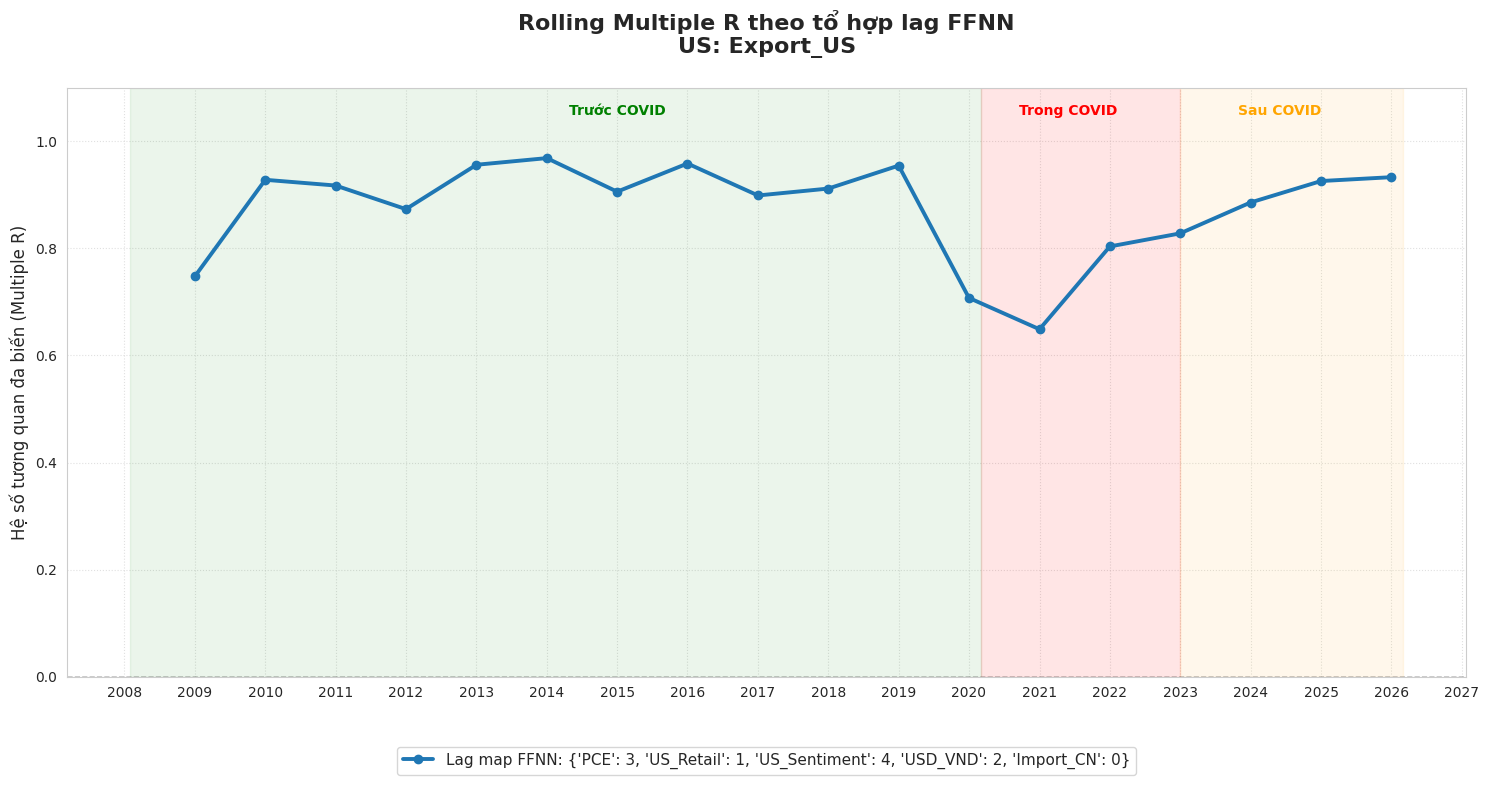

,Rolling Multiple R
TIME_PERIOD,
2019-01-01,0.95
2020-01-01,0.71
2021-01-01,0.65
2022-01-01,0.80
2023-01-01,0.83
2024-01-01,0.89
2025-01-01,0.93
2026-01-01,0.93


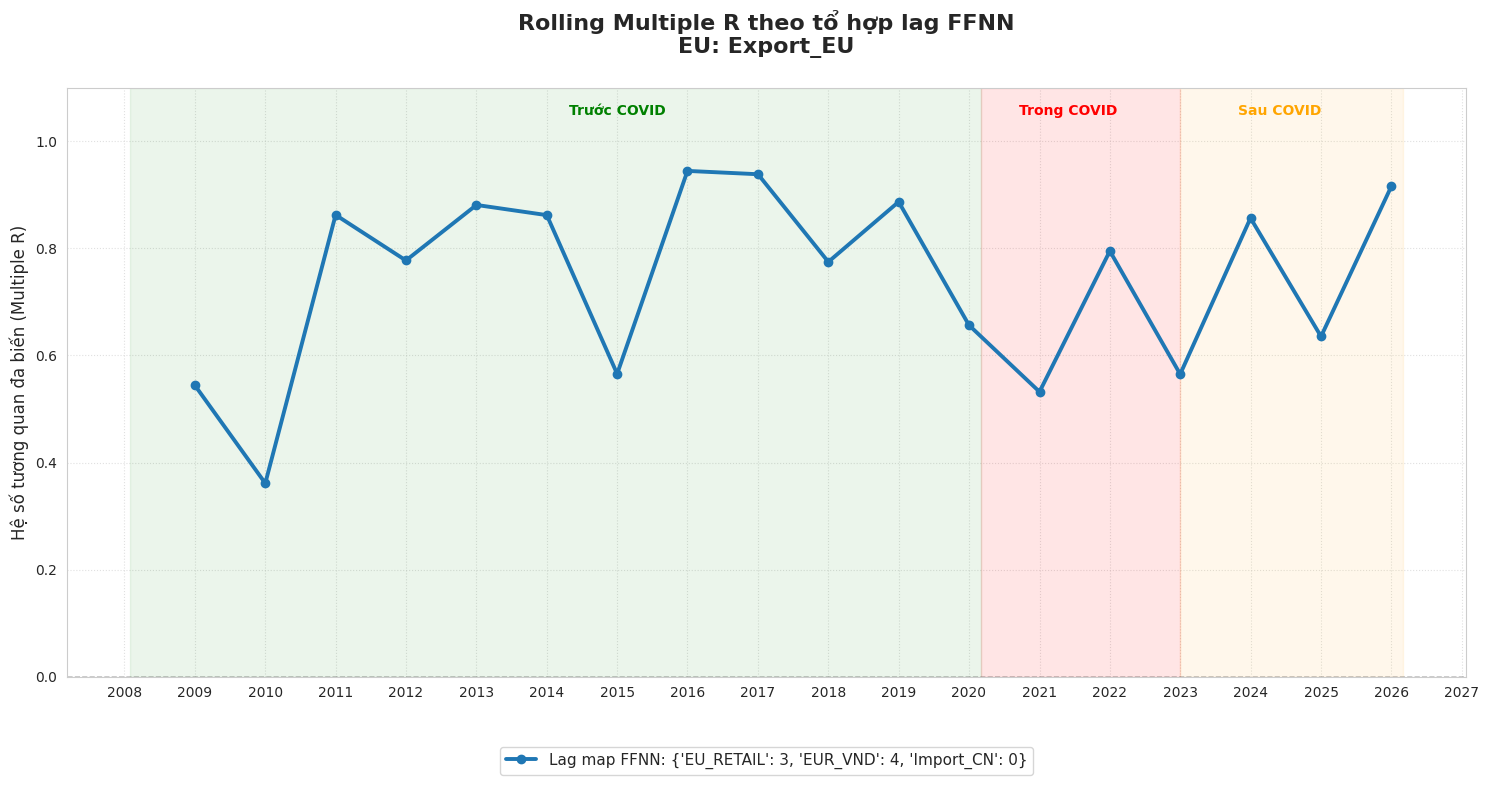

,Rolling Multiple R
TIME_PERIOD,
2019-01-01,0.89
2020-01-01,0.66
2021-01-01,0.53
2022-01-01,0.80
2023-01-01,0.56
2024-01-01,0.86
2025-01-01,0.64
2026-01-01,0.92


In [ ]:
def rolling_multiple_r_for_lag_map(df_stationary, target_var, lag_map, window=12):
    X_temp = build_lagged_exog(df_stationary, lag_map)
    data_combined = pd.concat([df_stationary[target_var], X_temp], axis=1).dropna()
    Y = data_combined[target_var]
    X_model = sm.add_constant(data_combined.drop(columns=[target_var]))
    rolling_model = RollingOLS(endog=Y, exog=X_model, window=window)
    rolling_res = rolling_model.fit()
    return np.sqrt(rolling_res.rsquared).resample('YS').mean()

def plot_ffnn_lag_map_rolling_r(df_stationary, target_var, lag_map, market_name, window=12):
    fig, ax = plt.subplots(figsize=(15, 8))
    df_yearly = rolling_multiple_r_for_lag_map(df_stationary, target_var, lag_map, window=window)
    ax.plot(df_yearly.index, df_yearly, color='#1f77b4', linewidth=2.8,
            marker='o', markersize=6, label=f'Lag map FFNN: {lag_map}')

    covid_start = pd.to_datetime('2020-03-01')
    covid_end = pd.to_datetime('2023-01-01')
    start_date = df_stationary.index.min()
    end_date = df_stationary.index.max()

    ax.axvspan(start_date, covid_start, color='green', alpha=0.08)
    ax.axvspan(covid_start, covid_end, color='red', alpha=0.1)
    ax.axvspan(covid_end, end_date, color='orange', alpha=0.08)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')

    ax.text(pd.to_datetime('2015-01-01'), 1.05, 'Trước COVID', ha='center', color='green', fontweight='bold')
    ax.text(pd.to_datetime('2021-06-01'), 1.05, 'Trong COVID', ha='center', color='red', fontweight='bold')
    ax.text(pd.to_datetime('2024-06-01'), 1.05, 'Sau COVID', ha='center', color='orange', fontweight='bold')

    ax.set_title(f'Rolling Multiple R theo tổ hợp lag FFNN\n{market_name}: {target_var}', fontsize=16, fontweight='bold', pad=25)
    ax.set_ylabel('Hệ số tương quan đa biến (Multiple R)', fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.18), ncol=1, fontsize=11)

    plt.tight_layout()
    plt.savefig(f'Rolling_Multiple_R_FFNN_Lag_Map_{market_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    display(df_yearly.to_frame('Rolling Multiple R').round(4).tail(8))
    return df_yearly

rolling_r_US = plot_ffnn_lag_map_rolling_r(df_US_VN_diff, target_var_US, best_lag_map_US, 'US')
rolling_r_EU = plot_ffnn_lag_map_rolling_r(df_EU_VN_diff, target_var_EU, best_lag_map_EU, 'EU')




##### Nhận xét Rolling Multiple R theo lag FFNN

Khác với phiên bản cũ so sánh các lag chung, biểu đồ này đánh giá sức giải thích của toàn bộ hệ biến khi mỗi biến được đặt tại lag riêng tốt nhất do FFNN chọn. Nếu Rolling Multiple R duy trì cao, tổ hợp lag FFNN không chỉ tốt trên validation/test mà còn giữ được sức giải thích theo thời gian. Nếu đường giảm ở giai đoạn hậu COVID, điều đó cho thấy quan hệ xuất khẩu - biến dẫn dắt đang yếu đi hoặc bị chi phối bởi yếu tố ngoài mô hình.


## Tổng Hợp Phân Tích

### Cách đọc phần tổng hợp phân tích

Từ phần này trở đi, notebook chuyển từ “xây dựng mô hình” sang “rút insight”. Các kết quả được gom theo từng chủ đề để trả lời trực tiếp câu hỏi nghiên cứu:

- Xuất khẩu Việt Nam có tăng trưởng thực chất không?
- Tỷ giá hỗ trợ hay gây nhiễu cho xuất khẩu?
- Tiêu dùng Mỹ/EU có phải chỉ báo quan trọng không?
- Độ trễ tác động nằm ở khoảng nào?
- Mức độ nhạy cảm của xuất khẩu trước sức cầu quốc tế mạnh hay yếu?


### 1. Phân tích ảnh hưởng của tỷ giá đến hoạt động thương mại

Mục tiêu:
-  Đánh giá tác động của USD/VND đến khả năng cạnh tranh của hàng hóa Việt Nam,
-  Giá trị xuất khẩu
-  Sự khác biệt giữa thị trường Mỹ, EU.

### Tương Quan Trượt (Rolling Correlation): Tỷ Giá vs Xuất Khẩu

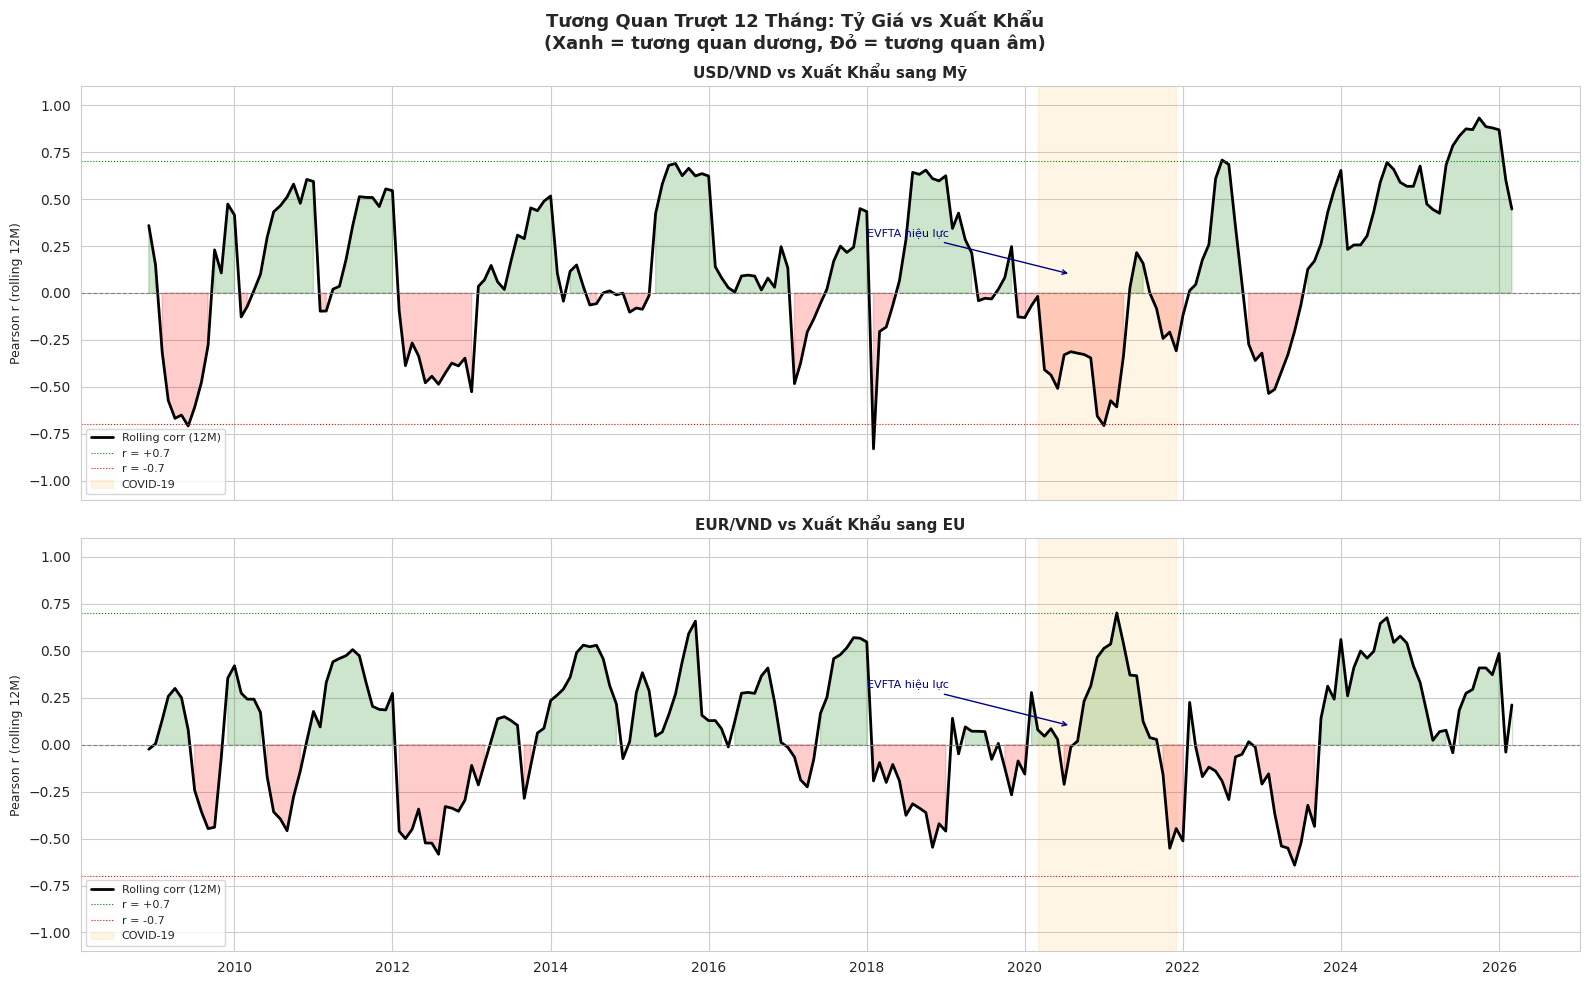

In [ ]:
# Rolling correlation 12 tháng — thấy mối quan hệ thay đổi theo thời gian
window = 12

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

pairs = [
    ('USD_VND', 'Export_US', 'USD/VND vs Xuất Khẩu sang Mỹ', 'steelblue', 'crimson'),
    ('EUR_VND', 'Export_EU', 'EUR/VND vs Xuất Khẩu sang EU',  'seagreen',  'darkorange'),
]

for ax, (c_fx, c_ex, title, col_fx, col_ex) in zip(axes, pairs):
    roll_corr = df_ts[c_fx].rolling(window).corr(df_ts[c_ex])

    ax.plot(roll_corr.index, roll_corr.values, linewidth=2, color='black', label='Rolling corr (12M)')
    ax.axhline(0,    color='grey',  linewidth=0.8, linestyle='--')
    ax.axhline(0.7,  color='green', linewidth=0.8, linestyle=':', label='r = +0.7')
    ax.axhline(-0.7, color='red',   linewidth=0.8, linestyle=':', label='r = -0.7')
    ax.fill_between(roll_corr.index, roll_corr.values, 0,
                    where=(roll_corr.values > 0), alpha=0.2, color='green')
    ax.fill_between(roll_corr.index, roll_corr.values, 0,
                    where=(roll_corr.values < 0), alpha=0.2, color='red')

    # Đánh dấu giai đoạn
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-12-01'),
               alpha=0.10, color='orange', label='COVID-19')
    ax.axvspan(pd.Timestamp('2020-08-01'), pd.Timestamp('2020-08-31'),
               alpha=0, color='none')  # spacer

    # Chú thích EVFTA
    ax.annotate('EVFTA hiệu lực', xy=(pd.Timestamp('2020-08-01'), 0.1),
                fontsize=8, color='navy',
                arrowprops=dict(arrowstyle='->', color='navy'),
                xytext=(pd.Timestamp('2018-01-01'), 0.3))

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Pearson r (rolling 12M)', fontsize=9)
    ax.set_ylim(-1.1, 1.1)
    ax.legend(fontsize=8, loc='lower left')

plt.suptitle('Tương Quan Trượt 12 Tháng: Tỷ Giá vs Xuất Khẩu\n'
             '(Xanh = tương quan dương, Đỏ = tương quan âm)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


 **Đánh giá:**

USD/VND vs Export_US: Tương quan không ổn định và dao động mạnh trong suốt 18 năm, xen kẽ giữa dương và âm nhiều lần — không phải chỉ trong COVID. Có thể nhận ra 4 chế độ chính:

- 2008–2010: dao động âm-dương, phản ánh giai đoạn hỗn loạn hậu khủng hoảng tài chính toàn cầu. Tỷ giá biến động mạnh do áp lực thị trường, chưa phản ánh quan hệ thương mại ổn định.
- 2011–2016: xen kẽ dương và âm theo chu kỳ ngắn, tương quan trung bình thấp. Giai đoạn này xuất khẩu Việt Nam sang Mỹ còn nhỏ (~1–4 tỷ USD/tháng), tỷ giá chưa phải yếu tố quyết định.
- 2017–2019: tương quan dương khá ổn định, thường xuyên vượt +0.5 — giai đoạn tỷ giá và xuất khẩu đồng pha rõ nhất trước COVID. Chiến tranh thương mại Mỹ–Trung (2018–2019) bắt đầu đẩy đơn hàng sang Việt Nam, làm tăng độ nhạy giữa hai biến.
- 2020–2021 (COVID): tương quan lao dốc xuống −0.8 — mức âm mạnh nhất trong lịch sử dữ liệu. USD/VND tăng (VND mất giá) nhưng xuất khẩu không tăng tương ứng do đứt gãy logistics và đóng cửa nhà máy. Lần đầu tiên tỷ giá và xuất khẩu đi ngược chiều mạnh trong thời gian dài.
- 2022–2026: phục hồi dương, nhiều tháng vượt ngưỡng +0.7. Tỷ giá tiếp tục là yếu tố hỗ trợ cạnh tranh trong điều kiện bình thường mới.

EUR/VND vs Export_EU: Biến động tương tự nhưng biên độ nhỏ hơn và ít vượt ngưỡng ±0.7. Điểm đáng chú ý: trước 2020 tương quan dao động không rõ xu hướng, phản ánh EUR/VND không phải yếu tố chi phối xuất khẩu sang EU khi thuế quan còn cao. Sau 2020, rolling correlation trở nên tích cực và duy trì ổn định hơn — dấu hiệu EVFTA đang làm cho tỷ giá EUR có ý nghĩa hơn với hoạt động xuất khẩu.

### Tỷ Giá vs Xuất Khẩu Theo Giai Đoạn

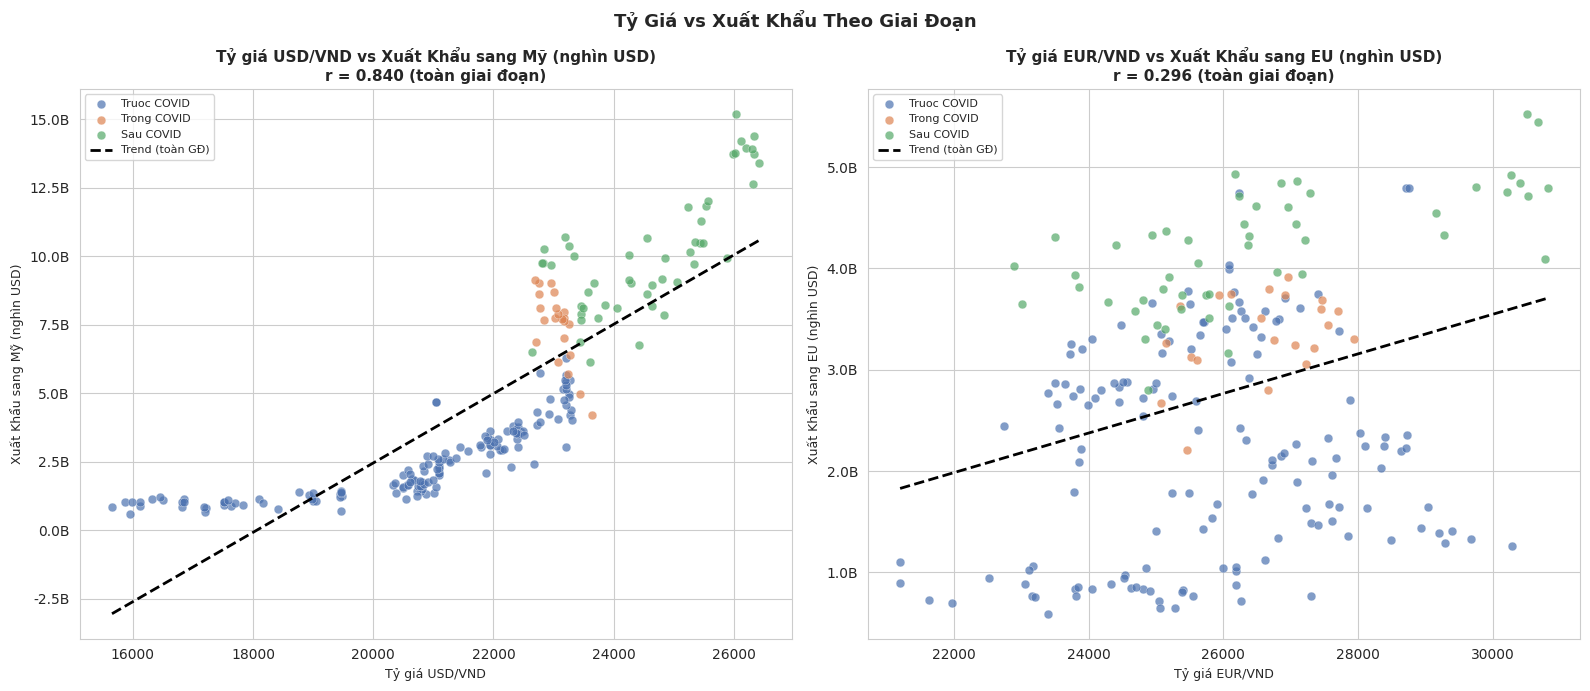

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

phase_map = df.copy()
phase_map['phase'] = 'Truoc COVID'
phase_map.loc[phase_map['TIME_PERIOD'] >= '2020-03-01', 'phase'] = 'Trong COVID'
phase_map.loc[phase_map['TIME_PERIOD'] >  '2021-12-31', 'phase'] = 'Sau COVID'

colors_phase = {'Truoc COVID': '#4C72B0', 'Trong COVID': '#DD8452', 'Sau COVID': '#55A868'}

for ax, (c_fx, c_ex, lbl_fx, lbl_ex) in zip(axes, [
    ('USD_VND', 'Export_US', 'Tỷ giá USD/VND', 'Xuất Khẩu sang Mỹ (nghìn USD)'),
    ('EUR_VND', 'Export_EU', 'Tỷ giá EUR/VND', 'Xuất Khẩu sang EU (nghìn USD)'),
]):
    for phase, color in colors_phase.items():
        sub = phase_map[phase_map['phase'] == phase]
        ax.scatter(sub[c_fx], sub[c_ex], color=color, alpha=0.7,
                   s=40, label=phase, edgecolors='white', linewidth=0.3)

    # Regression line toàn bộ
    from numpy.polynomial.polynomial import polyfit
    xy = phase_map[[c_fx, c_ex]].dropna()
    b, m = polyfit(xy[c_fx], xy[c_ex], 1)
    x_line = pd.Series([xy[c_fx].min(), xy[c_fx].max()])
    ax.plot(x_line, b + m * x_line, color='black', linewidth=2,
            linestyle='--', label=f'Trend (toàn GĐ)')

    r_all = xy.corr().iloc[0, 1]
    ax.set_title(f'{lbl_fx} vs {lbl_ex}\nr = {r_all:.3f} (toàn giai đoạn)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(lbl_fx, fontsize=9)
    ax.set_ylabel(lbl_ex, fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}B'))
    ax.legend(fontsize=8)

plt.suptitle('Tỷ Giá vs Xuất Khẩu Theo Giai Đoạn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


USD/VND vs Export_US (r = 0.840 toàn giai đoạn):
Scatter plot cho thấy ba đám điểm phân tách rõ ràng theo giai đoạn — đây là bằng chứng trực quan mạnh nhất về sự thay đổi cấu trúc:

- Điểm xanh (Trước COVID): tập trung ở góc dưới-trái (USD/VND thấp ~16.000–23.000, xuất khẩu thấp ~0.5–4 tỷ). Phân bố dọc theo đường trend — quan hệ tuyến tính khá chặt.
- Điểm cam (Trong COVID): cụm tại USD/VND ~23.000–24.500 nhưng xuất khẩu vọt lên ~5–9 tỷ — nằm trên đường trend, tức xuất khẩu cao hơn mức tỷ giá dự báo. Đây là hiệu ứng stimulus Mỹ: tiêu dùng bùng nổ bất kể tỷ giá.
- Điểm xanh lá (Sau COVID): USD/VND cao ~24.000–26.500, xuất khẩu ~6–15 tỷ. Phân tán rộng hơn, nhiều điểm nằm trên đường trend — xuất khẩu tiếp tục vượt mức tỷ giá thuần túy giải thích được, hàm ý có cả yếu tố cấu trúc (dịch chuyển chuỗi cung ứng) đang cộng hưởng.

Tóm lại: đường trend toàn giai đoạn có hệ số góc dương — VND mất giá nhìn chung đi kèm xuất khẩu tăng. Nhưng từng giai đoạn có độ lệch khác nhau so với đường trend, cho thấy tỷ giá không phải yếu tố duy nhất và không đủ để giải thích toàn bộ biến động.

EUR/VND vs Export_EU (r = 0.296 toàn giai đoạn):
Scatter phân tán rộng hơn nhiều, đường trend thoải — tương quan yếu ở cấp độ toàn giai đoạn. Điểm xanh (Trước COVID) nằm rải rác không theo xu hướng rõ ràng, xác nhận EUR/VND chưa có tác động đáng kể lên xuất khẩu EU khi thuế quan còn là rào cản chính. Điểm xanh lá (Sau COVID) cụm lại ở góc trên-phải với EUR/VND cao và xuất khẩu cao — dấu hiệu mối quan hệ dương đang hình thành. Scatter này trực quan hóa rõ tại sao r toàn giai đoạn chỉ 0.296 nhưng r sau COVID lên đến 0.66 — vì trước EVFTA hai biến gần như độc lập.

### 2. Phân tích mối quan hệ giữa các chỉ số tiêu dùng và nhập khẩu đến xuất khẩu (Rolling Regression)

**Từ tỷ giá sang sức cầu tiêu dùng**

Phân tích tỷ giá cho thấy tỷ giá có liên hệ với xuất khẩu, nhưng quan hệ này không ổn định và thay đổi theo giai đoạn. Điều đó gợi ý rằng tỷ giá không phải yếu tố duy nhất giải thích xuất khẩu Việt Nam.

Vì vậy, bước tiếp theo tập trung vào nhóm biến tiêu dùng như `PCE`, `US_Retail`, `US_Sentiment` và `EU_RETAIL`. Đây là các biến phản ánh trực tiếp hơn nhu cầu mua hàng từ thị trường nhập khẩu, nên có khả năng giải thích tốt hơn sự thay đổi trong đơn hàng xuất khẩu.

Đánh giá tác động của:
-  PCE
-  US_Retail
-  US_Sentiment
-  USD_VND
-  EUR_VND
-  EU_Retail

Đối với xuất khẩu Việt Nam sang Mỹ và EU.


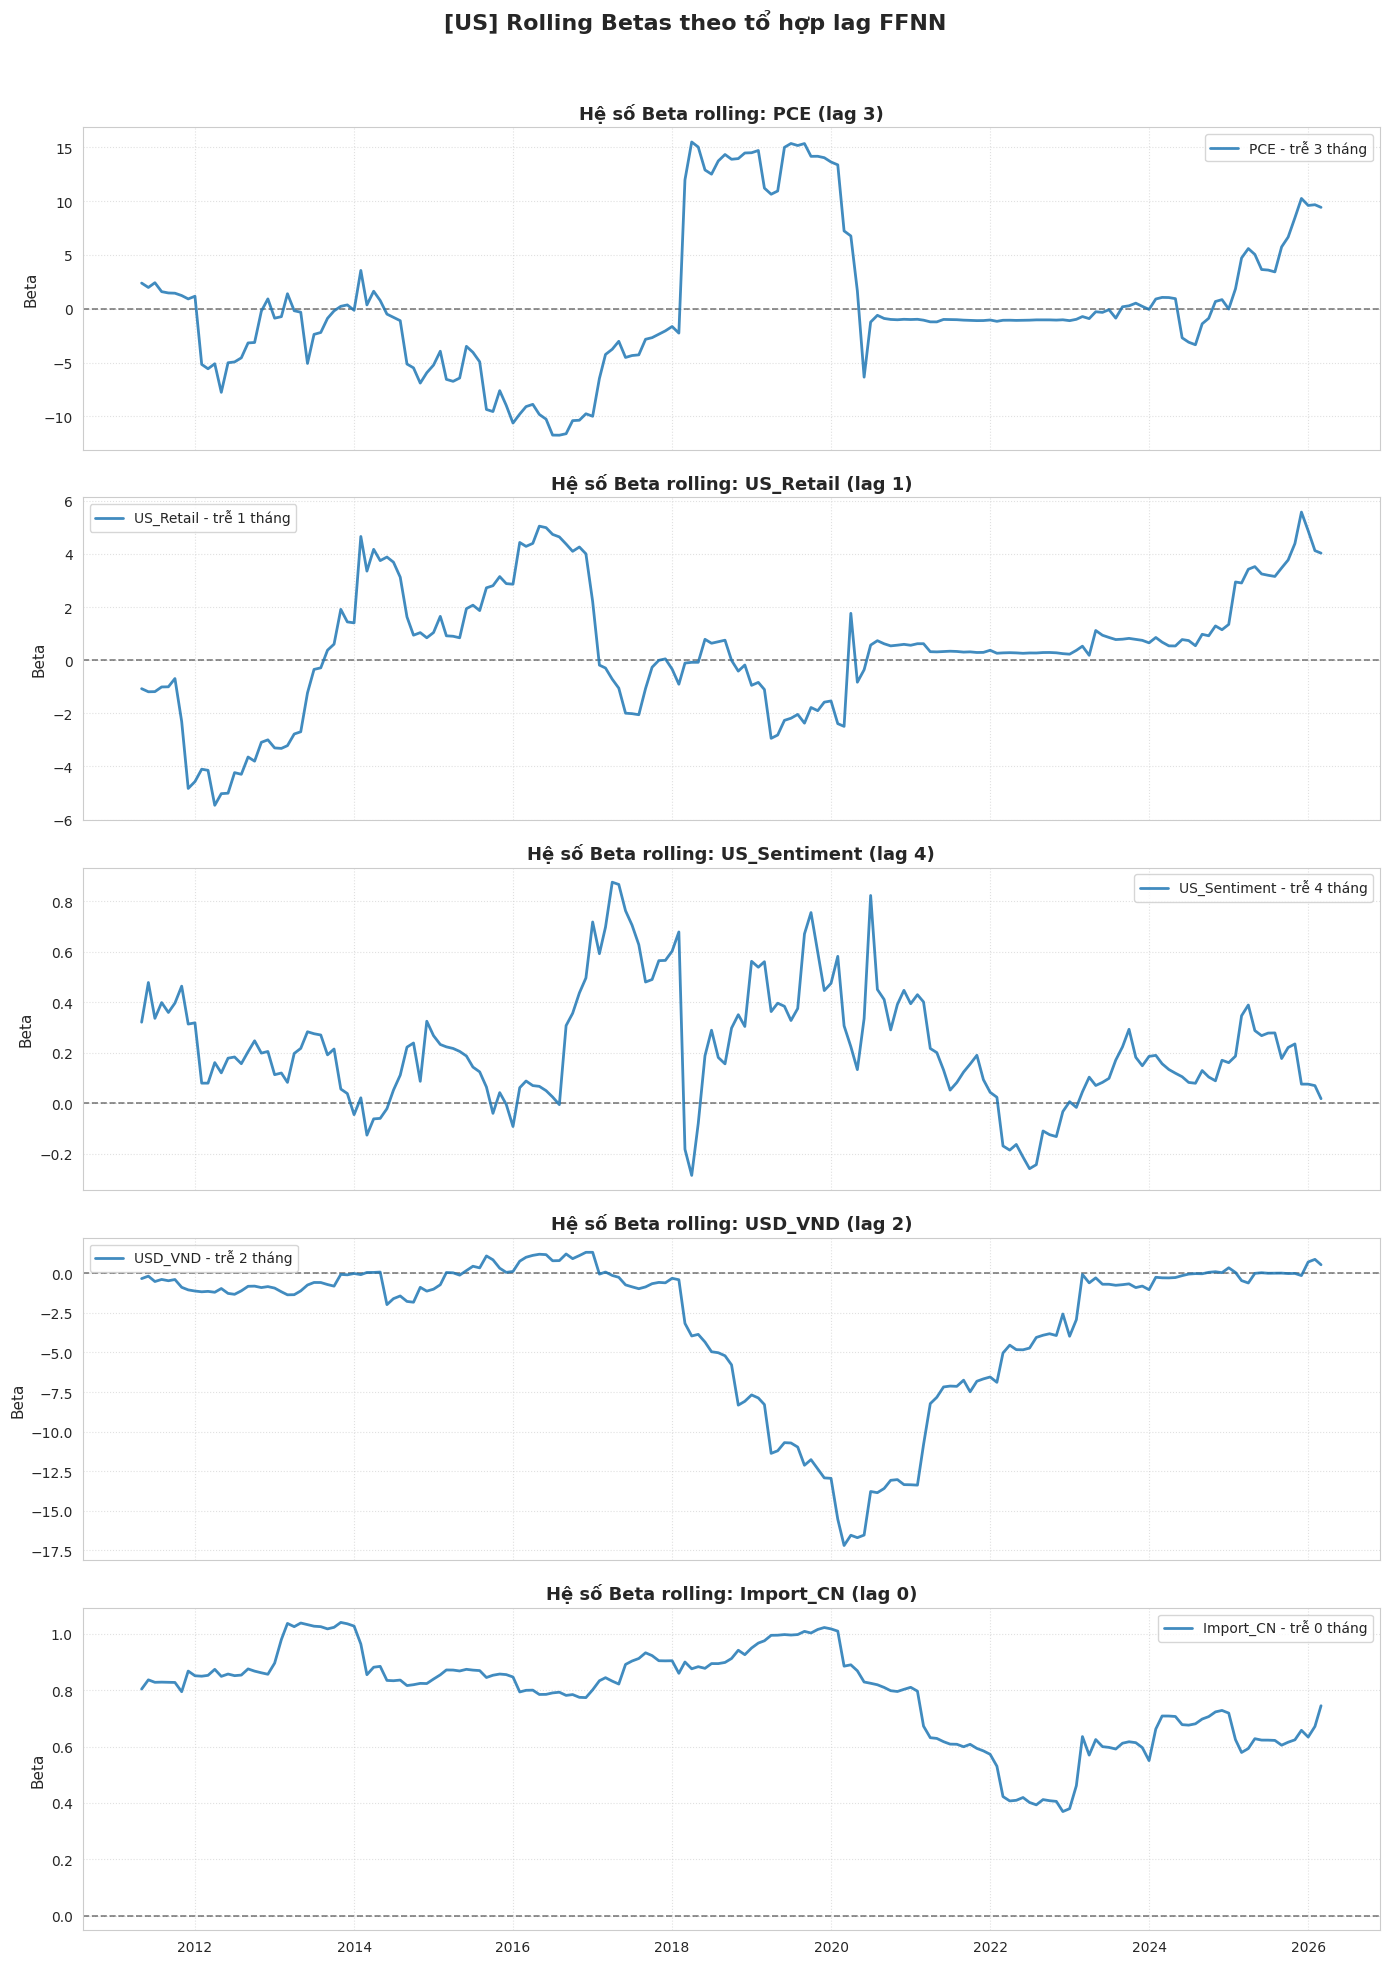

,Biến,Lag FFNN,Beta hiện tại,Beta trung bình,Độ biến động (Std),Beta min,Beta max
0,PCE,3,9.41,0.39,6.70,-11.75,15.48
1,US_Retail,1,4.03,0.44,2.35,-5.46,5.57
2,US_Sentiment,4,0.02,0.22,0.23,-0.29,0.88
3,USD_VND,2,0.54,-3.12,4.68,-17.20,1.33
4,Import_CN,0,0.74,0.78,0.16,0.37,1.04


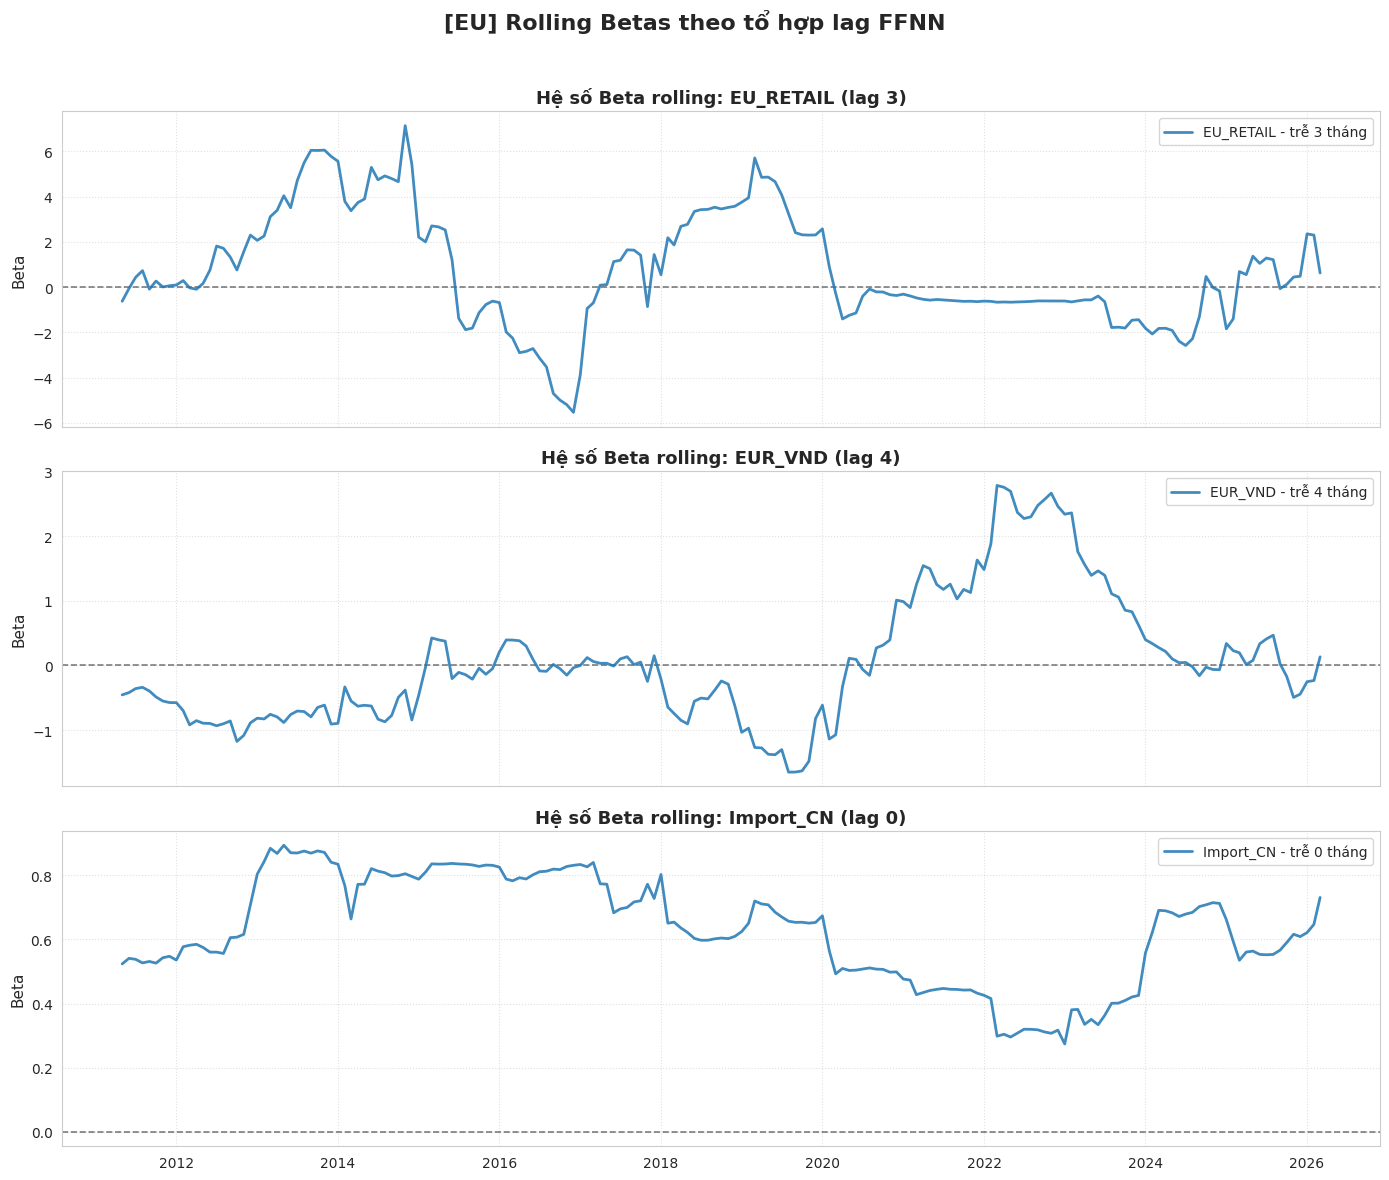

,Biến,Lag FFNN,Beta hiện tại,Beta trung bình,Độ biến động (Std),Beta min,Beta max
0,EU_RETAIL,3,0.63,0.73,2.47,-5.54,7.14
1,EUR_VND,4,0.13,0.05,0.98,-1.65,2.78
2,Import_CN,0,0.73,0.63,0.16,0.27,0.89


In [ ]:
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

def plot_beta_by_ffnn_lag_map(df_stationary, target_var, lag_map, market_name, window=36):
    variables = list(lag_map.keys())
    X_temp = build_lagged_exog(df_stationary, lag_map)
    data_model = pd.concat([df_stationary[target_var], X_temp], axis=1).dropna()
    Y = data_model[target_var]
    X_model = sm.add_constant(data_model.drop(columns=[target_var]))

    rolling_model = RollingOLS(endog=Y, exog=X_model, window=window)
    rolling_results = rolling_model.fit()

    fig, axes = plt.subplots(nrows=len(variables), ncols=1, figsize=(14, 4 * len(variables)), sharex=True)
    if len(variables) == 1:
        axes = [axes]

    fig.suptitle(f'[{market_name}] Rolling Betas theo tổ hợp lag FFNN', fontsize=16, fontweight='bold', y=0.98)
    stats_rows = []

    for ax, var in zip(axes, variables):
        lag = int(lag_map[var])
        beta_col = f'{var}_Lag{lag}'
        series_beta = rolling_results.params[beta_col].dropna()

        ax.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1.2)
        ax.plot(series_beta.index, series_beta, color='#1f77b4', linewidth=2, alpha=0.85,
                label=f'{var} - trễ {lag} tháng')
        ax.set_title(f'Hệ số Beta rolling: {var} (lag {lag})', fontsize=13, fontweight='bold')
        ax.set_ylabel('Beta', fontsize=11)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='best', fontsize=10)

        stats_rows.append({
            'Biến': var,
            'Lag FFNN': lag,
            'Beta hiện tại': series_beta.iloc[-1],
            'Beta trung bình': series_beta.mean(),
            'Độ biến động (Std)': series_beta.std(),
            'Beta min': series_beta.min(),
            'Beta max': series_beta.max()
        })

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f'Beta_FFNN_Lag_Map_{market_name}.png', dpi=300, bbox_inches='tight')
    plt.show()

    beta_summary = pd.DataFrame(stats_rows)
    display(beta_summary.round(4))
    return beta_summary, rolling_results

beta_summary_US, rolling_beta_US = plot_beta_by_ffnn_lag_map(df_US_VN_diff, target_var_US, best_lag_map_US, 'US')
beta_summary_EU, rolling_beta_EU = plot_beta_by_ffnn_lag_map(df_EU_VN_diff, target_var_EU, best_lag_map_EU, 'EU')



##### Nhận xét Rolling Beta theo lag FFNN

Bảng Rolling Beta cho biết dấu và độ ổn định của từng biến tại chính lag mà FFNN chọn. Cần đọc kết quả theo hai lớp: beta hiện tại cho biết tác động gần cuối chuỗi, còn độ lệch chuẩn và khoảng min-max cho biết quan hệ đó có ổn định qua thời gian hay không. Các biến có beta đổi dấu mạnh giữa min và max nên được xem là tín hiệu biến thiên theo bối cảnh, không phải quan hệ cố định.


### 4. Đo lường mức độ nhạy cảm của xuất khẩu Việt Nam đối với tiêu dùng Mỹ và EU

**Lưu ý khi diễn giải elasticity**

Elasticity giúp đo mức độ nhạy cảm của xuất khẩu trước thay đổi của biến tiêu dùng. Tuy nhiên, dù đã lấy log nhưng mô hình được chạy trên dữ liệu có trend, hệ số có thể bị phóng đại do các biến cùng tăng theo thời gian.

Vì vậy, kết quả elasticity sẽ được diễn giải theo hướng:

> Xuất khẩu Việt Nam có mức độ đồng biến và nhạy cảm cao với sức cầu tiêu dùng tại Mỹ/EU.

Không thể diễn giải quá mạnh thành quan hệ nhân quả tuyệt đối như “tiêu dùng tăng chắc chắn làm xuất khẩu tăng đúng bằng từng đó phần trăm”. Đây là điểm cần ghi rõ để bài phân tích chặt chẽ hơn.

Xác định:
-  Khi sức mua tại Mỹ/EU tăng hoặc giảm, kim ngạch xuất khẩu Việt Nam phản ứng mạnh hay yếu
-  Mức độ phụ thuộc của xuất khẩu Việt Nam vào nhu cầu tiêu dùng quốc tế.

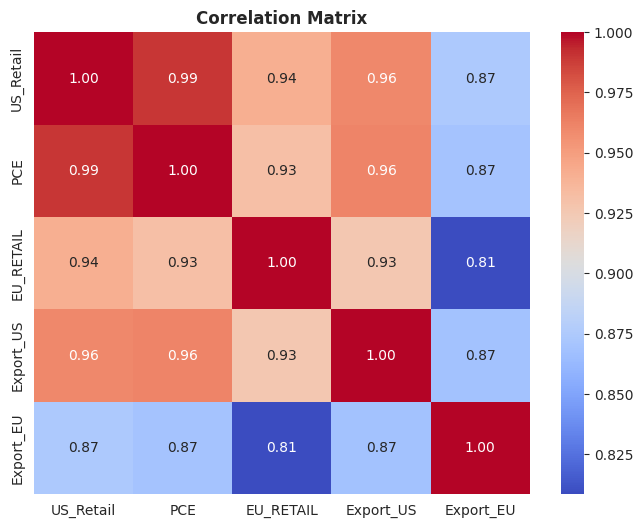

PHÂN TÍCH MỨC ĐỘ NHẠY CẢM

KẾT QUẢ ELASTICITY


,Cặp biến (Y ~ X),Elasticity,R-squared,p-value
0,Export_US ~ US_Retail,3.40,0.93,0.00
1,Export_US ~ PCE,3.37,0.91,0.00
2,Export_EU ~ EU_RETAIL,5.46,0.53,0.00


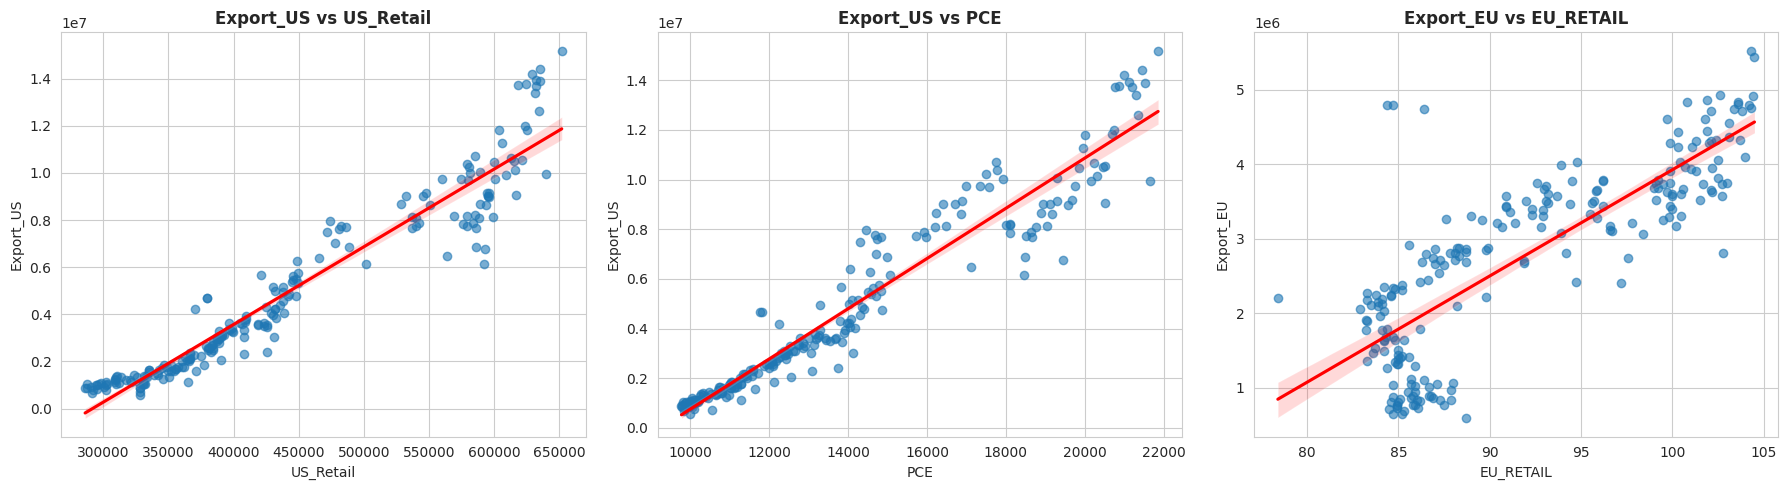

In [ ]:
#  DANH SÁCH CÁC CẶP BIẾN PHÂN TÍCH ĐỘ NHẠY CẢM
pairs = [
    ("Export_US", "US_Retail"),
    ("Export_US", "PCE"),
    ("Export_EU", "EU_RETAIL")
]

# 2. PHÂN TÍCH TƯƠNG QUAN (CORRELATION)
corr_cols = [
    "US_Retail",
    "PCE",
    "EU_RETAIL",
    "Export_US",
    "Export_EU"
]

corr_matrix = df[corr_cols].corr()

# TRỰC QUAN HÓA MA TRẬN TƯƠNG QUAN
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix",
    fontweight="bold"
)

plt.show()

# PHÂN TÍCH MỨC ĐỘ NHẠY CẢM (ELASTICITY MODEL)
sensitivity_results = []

print("PHÂN TÍCH MỨC ĐỘ NHẠY CẢM")

for y_col, x_col in pairs:

    # Lấy dữ liệu cần thiết
    sub_df = df[[y_col, x_col]].dropna()

    # Chỉ giữ giá trị > 0 để lấy log
    sub_df = sub_df[
        (sub_df[y_col] > 0) &
        (sub_df[x_col] > 0)
    ]

    # MÔ HÌNH LOG-LOG
    log_y = np.log(sub_df[y_col])

    log_x = np.log(sub_df[x_col])

    # Thêm hệ số chặn
    log_x = sm.add_constant(log_x)

    # Hồi quy OLS
    model = sm.OLS(log_y, log_x).fit()

    # Lấy kết quả
    elasticity = model.params[x_col]
    r_squared = model.rsquared
    p_value = model.pvalues[x_col]

    sensitivity_results.append({
        "Cặp biến (Y ~ X)": f"{y_col} ~ {x_col}",
        "Elasticity": round(elasticity, 3),
        "R-squared": round(r_squared, 3),
        "p-value": round(p_value, 4)
    })

# Chuyển sang DataFrame
sensitivity_df = pd.DataFrame(sensitivity_results)

print("\nKẾT QUẢ ELASTICITY")

display(sensitivity_df)

# TRỰC QUAN HÓA SCATTER + REGRESSION LINE

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for i, (y_col, x_col) in enumerate(pairs):

    sns.regplot(
        data=df,
        x=x_col,
        y=y_col,
        ax=axes[i],
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "red"}
    )

    axes[i].set_title(
        f"{y_col} vs {x_col}",
        fontweight="bold"
    )

    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)

plt.tight_layout()

plt.show()


Kết quả phân tích cho thấy **xuất khẩu Việt Nam có mối liên hệ rất chặt chẽ với nhu cầu tiêu dùng tại Mỹ và EU**. Cụ thể, Export_US có tương quan gần như tuyệt đối với PCE **(0.96)** và US_Retail **(0.96)**, phản ánh rằng sức mua của người tiêu dùng Mỹ chính là động lực quan trọng đối với xuất khẩu Việt Nam. **Khi doanh số bán lẻ và chi tiêu tiêu dùng tại Mỹ tăng, kim ngạch xuất khẩu của Việt Nam cũng tăng gần như song song**. Tương tự, Export_EU và EU_RETAIL có hệ số tương quan cao **(0.81)**, cho thấy xuất khẩu sang EU cũng phụ thuộc mạnh vào nhu cầu bán lẻ nội địa của thị trường này.

Bên cạnh đó, mô hình Log-Log cho thấy các hệ số co giãn (Elasticity) đều lớn hơn 1, chứng tỏ **xuất khẩu Việt Nam phản ứng rất mạnh trước sự thay đổi của sức mua quốc tế**. Đặc biệt, mô hình Export_EU ~ EU_RETAIL có hệ số co giãn **5.459**, nghĩa là khi doanh số bán lẻ tại EU tăng 1% thì xuất khẩu của Việt Nam sang EU có thể tăng khoảng 5.46%. Đối với thị trường Mỹ, các hệ số co giãn khoảng 3.37–3.40 cũng cho thấy mức phản ứng rất mạnh của xuất khẩu trước thay đổi trong chi tiêu tiêu dùng Mỹ.

Ngoài ra, chỉ số R² của các mô hình Export_US ~ PCE **(0.914)** và Export_US ~ US_Retail **(0.928)** đều rất cao, cho thấy hơn 90% biến động của xuất khẩu sang Mỹ được giải thích bởi nhu cầu tiêu dùng Mỹ. Điều này khẳng định **mức độ phụ thuộc rất lớn của xuất khẩu Việt Nam vào thị trường Mỹ**. Trong khi đó, mô hình Export_EU ~ EU_RETAIL có R² = **0.531**, cho thấy xuất khẩu sang EU tuy phản ứng mạnh với tiêu dùng nhưng vẫn chịu ảnh hưởng bởi nhiều yếu tố khác như chính sách thương mại, logistics, tỷ giá và điều kiện kinh tế khu vực.

**Kết nối insight từ correlation và elasticity**

Correlation cho thấy các biến tiêu dùng và xuất khẩu có xu hướng đi cùng nhau, còn elasticity cho biết xuất khẩu phản ứng mạnh hay yếu trước biến động của sức cầu. Khi hai kết quả này cùng cho tín hiệu mạnh, có thể kết luận rằng sức cầu quốc tế là một yếu tố quan trọng trong câu chuyện xuất khẩu Việt Nam.

Tuy nhiên, kết quả cũng cho thấy sự khác biệt giữa hai thị trường: Mỹ có mối liên hệ mạnh và rõ hơn với xuất khẩu Việt Nam, trong khi EU ổn định hơn nhưng mức giải thích thấp hơn. Điều này hàm ý chiến lược thị trường cần khác nhau: Mỹ là thị trường tăng trưởng mạnh nhưng biến động lớn, còn EU là thị trường ổn định hơn nhưng ít bùng nổ hơn.

## Xây dựng mô hình dự báo xu hướng xuất khẩu ngắn hạn (ARIMA)

### Vai trò của dự báo trong bài

Sau khi đã phân tích xu hướng, độ trễ và mức độ nhạy cảm, bước cuối cùng là thử dự báo ngắn hạn bằng ARIMA. Phần dự báo không nhằm khẳng định chính xác tuyệt đối giá trị xuất khẩu tương lai, mà nhằm trả lời câu hỏi thực tế hơn:

> Với các quy luật quá khứ của chuỗi xuất khẩu, xu hướng ngắn hạn sắp tới có khả năng biến động ra sao?

ARIMA phù hợp ở đây vì mô hình tập trung vào cấu trúc tự thân của chuỗi thời gian: giá trị hiện tại chịu ảnh hưởng từ các giá trị quá khứ và sai số quá khứ.

Ứng dụng:
-  Hồi quy tuyến tính
-  XGBoost đơn giản

Để dự báo xu hướng tăng/giảm của xuất khẩu Việt Nam trong tương lai gần.

### Kiểm định Tự tương quan (ACF) để nhận diện tính dừng và bậc MA

[ 1.         -0.38827976 -0.08694563  0.05399028 -0.04480904  0.05997316
 -0.16571857  0.08136605 -0.0761217   0.08539646 -0.10197676]


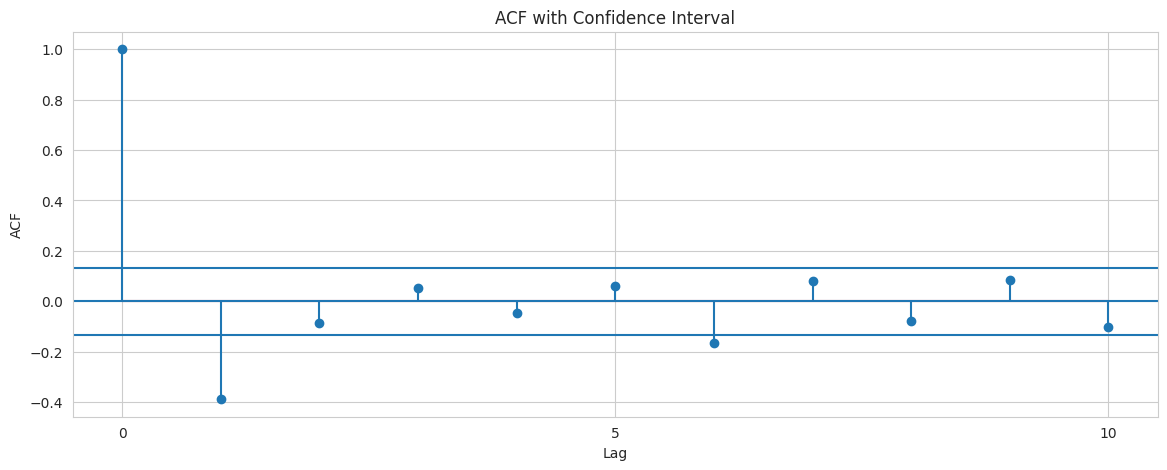

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

series = df_US_VN_diff.iloc[:,0]
n = len(series)

acf_vals = acf(series, nlags=10)
ci = 1.96 / np.sqrt(n)
print(acf_vals)

plt.figure()
plt.stem(range(len(acf_vals)), acf_vals)

plt.axhline(0)
plt.axhline(ci)
plt.axhline(-ci)

# ép trục x là số nguyên
plt.xticks(range(0, 11, 5))

plt.title("ACF with Confidence Interval")
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.show()


-  Giá trị ACF: Tại Lag 0 luôn là 1. Tại Lag 2, giá trị âm và không vượt qua ngưỡng khoảng tin cậy (CI).
-  Các lag sau đó (3, 4, 5...) nhỏ dần và dao động quanh mức 0.
-  Ngưỡng tin cậy: Với $n \approx 200$, CI nằm khoảng $\pm 0.138$.

**Nhận xét**:
-  Chuỗi dữ liệu sau khi lấy sai phân bậc 1 (diff) có ACF giảm rất nhanh về 0, chứng tỏ chuỗi đã dừng (stationary).
-  Việc ACF có giá trị đáng kể tại Lag 2 gợi ý mô hình có thể có thành phần MA(2), tức $q=2$

### Kiểm định Tự tương quan riêng phần (PACF) để nhận diện bậc AR

[ 1.         -0.38827976 -0.27990572 -0.12507942 -0.12251754 -0.01045302
 -0.20404727 -0.10224501 -0.20634545 -0.06124125 -0.21064688]


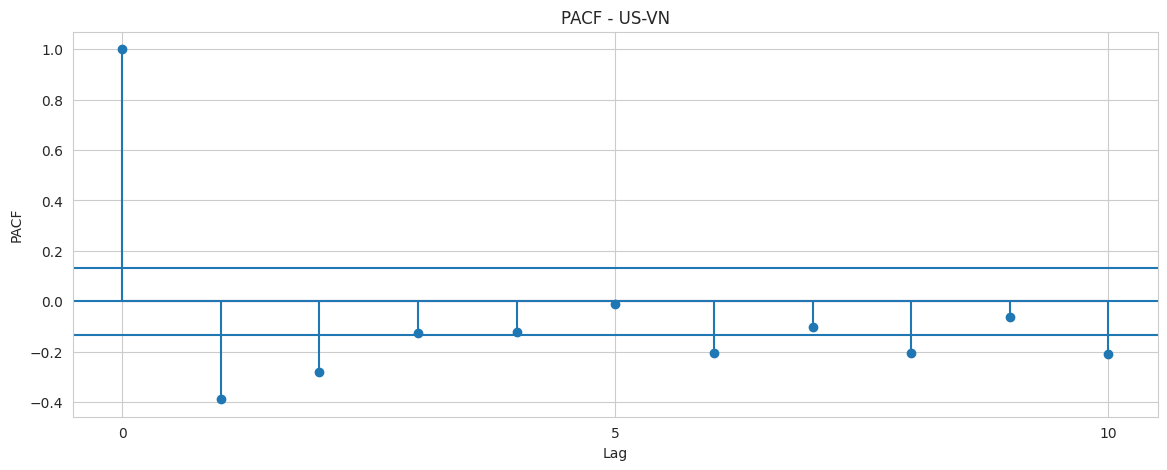

[ 1.         -0.35468206 -0.26589031 -0.26047849 -0.2599815  -0.14539312
 -0.25289593  0.03114536  0.10485749  0.04013799 -0.07196414]


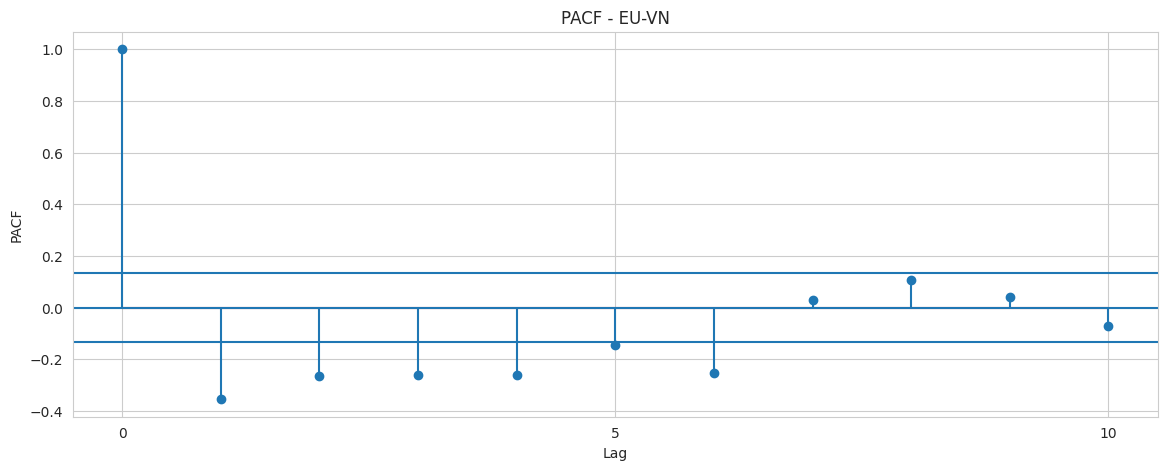

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import pacf

def plot_pacf_with_ci(series, name, lags=10):
    n = len(series)

    pacf_vals = pacf(series, nlags=lags, method='ywm')
    ci = 1.96 / np.sqrt(n)
    print(pacf_vals)

    plt.figure()
    plt.stem(range(len(pacf_vals)), pacf_vals)

    plt.axhline(0)
    plt.axhline(ci)
    plt.axhline(-ci)

    # ép trục x là số nguyên
    plt.xticks(range(0, lags+1, 5))

    plt.title(f"PACF - {name}")
    plt.xlabel("Lag")
    plt.ylabel("PACF")
    plt.show()

# chạy
plot_pacf_with_ci(df_US_VN_diff["Export_US"], "US-VN")
plot_pacf_with_ci(df_EU_VN_diff["Export_EU"], "EU-VN")


**Nhóm US-VN**: PACF tại Lag 2 có giá trị âm khoảng -0.213 (vượt ngưỡng tin cậy). Điều này lặp lại ở cả nhóm EU-VN với các biến số khác nhau.

**Nhóm EU-VN**: Có những biến (như dòng cuối cùng) cho thấy PACF tại Lag 1 và Lag 2 rất mạnh (âm), sau đó tắt dần.

**Nhận xét**:
-  PACF có ý nghĩa tại Lag 1 và Lag 2 cho thấy dữ liệu có tính phụ thuộc vào quá khứ gần. Điều này gợi ý bậc AR(2), tức $p=2$, là một ứng cử viên sáng giá cho mô hình.
-  Sự tương đồng giữa ACF và PACF (đều có dấu hiệu tại Lag 2) cho thấy mô hình hỗn hợp ARMA(2,2) có thể sẽ hoạt động tốt.
-  Dù lag 2 có dấu hiệu phù hợp nhất cho mô hình, ta vẫn sẽ chọn thêm các lag có độ tin cậy cao để thực hiện so sánh và tìm ra mô hình tối ưu nhất

### Tối ưu hóa tham số ARIMA (Grid Search)

In [ ]:
import itertools
from statsmodels.tsa.arima.model import ARIMA

# Chọn cột Export_US để đưa vào mô hình
series = df_US_VN_diff['Export_US'].dropna()

if isinstance(series.index, pd.DatetimeIndex):
    series = series.asfreq('MS')

# các giá trị p, d, q
p_values = [0, 1, 2, 6, 8]
d_values = [1]
q_values = [0, 2, 5, 9]

# lưu kết quả
results = []

# loop qua tất cả tổ hợp
for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(series, order=(p,d,q),enforce_stationarity=False,enforce_invertibility=False)
        fitted = model.fit()

        results.append({
            "p": p,
            "d": d,
            "q": q,
            "AIC": fitted.aic,
            "BIC": fitted.bic,
            "LogLik": fitted.llf
        })

        print(f"Done ARIMA({p},{d},{q})")

    except Exception as e:
        print(f"Fail ARIMA({p},{d},{q}): {e}")

# tạo dataframe kết quả
results_df_US = pd.DataFrame(results)

print(results_df_US)



Done ARIMA(0,1,0)
Done ARIMA(0,1,2)
Done ARIMA(0,1,5)
Done ARIMA(0,1,9)
Done ARIMA(1,1,0)
Done ARIMA(1,1,2)
Done ARIMA(1,1,5)
Done ARIMA(1,1,9)
Done ARIMA(2,1,0)
Done ARIMA(2,1,2)
Done ARIMA(2,1,5)
Done ARIMA(2,1,9)
Done ARIMA(6,1,0)
Done ARIMA(6,1,2)
Done ARIMA(6,1,5)
Done ARIMA(6,1,9)
Done ARIMA(8,1,0)
Done ARIMA(8,1,2)
Done ARIMA(8,1,5)
Done ARIMA(8,1,9)
    p  d  q     AIC     BIC  LogLik
0   0  1  0  113.89  117.26  -55.94
1   0  1  2 -156.79 -146.70   81.40
2   0  1  5 -156.85 -136.74   84.43
3   0  1  9 -151.57 -118.24   85.78
4   1  1  0   18.03   24.78   -7.02
5   1  1  2 -162.05 -148.59   85.03
6   1  1  5 -154.59 -131.13   84.30
7   1  1  9 -147.78 -111.12   84.89
8   2  1  0  -41.00  -30.89   23.50
9   2  1  2 -160.21 -143.38   85.10
10  2  1  5 -181.14 -154.33   98.57
11  2  1  9 -147.81 -107.82   85.90
12  6  1  0  -95.94  -72.48   54.97
13  6  1  2 -158.49 -128.32   88.25
14  6  1  5 -123.85  -83.62   73.92
15  6  1  9 -183.46 -130.14  107.73
16  8  1  0 -104.00  -73.92 

In [ ]:
# Chọn cột Export_EU để đưa vào mô hình
series = df_EU_VN_diff['Export_EU'].dropna()

if isinstance(series.index, pd.DatetimeIndex):
    series = series.asfreq('MS')

# các giá trị p, d, q
p_values = [0, 1, 2, 3, 4, 6]
d_values = [1]
q_values = [0, 2, 5, 9]

# lưu kết quả
results = []

# loop qua tất cả tổ hợp
for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        model = ARIMA(series, order=(p,d,q),enforce_stationarity=False,enforce_invertibility=False)
        fitted = model.fit()

        results.append({
            "p": p,
            "d": d,
            "q": q,
            "AIC": fitted.aic,
            "BIC": fitted.bic,
            "LogLik": fitted.llf
        })

        print(f"Done ARIMA({p},{d},{q})")

    except Exception as e:
        print(f"Fail ARIMA({p},{d},{q}): {e}")

# tạo dataframe kết quả
results_df_EU = pd.DataFrame(results)

print(results_df_EU)



Done ARIMA(0,1,0)
Done ARIMA(0,1,2)
Done ARIMA(0,1,5)
Done ARIMA(0,1,9)
Done ARIMA(1,1,0)
Done ARIMA(1,1,2)
Done ARIMA(1,1,5)
Done ARIMA(1,1,9)
Done ARIMA(2,1,0)
Done ARIMA(2,1,2)
Done ARIMA(2,1,5)
Done ARIMA(2,1,9)
Done ARIMA(3,1,0)
Done ARIMA(3,1,2)
Done ARIMA(3,1,5)
Done ARIMA(3,1,9)
Done ARIMA(4,1,0)
Done ARIMA(4,1,2)
Done ARIMA(4,1,5)
Done ARIMA(4,1,9)
Done ARIMA(6,1,0)
Done ARIMA(6,1,2)
Done ARIMA(6,1,5)
Done ARIMA(6,1,9)
    p  d  q     AIC     BIC  LogLik
0   0  1  0  101.91  105.28  -49.95
1   0  1  2 -172.14 -162.05   89.07
2   0  1  5 -172.79 -152.68   92.40
3   0  1  9 -167.93 -134.60   93.96
4   1  1  0   12.91   19.66   -4.46
5   1  1  2 -173.36 -159.90   90.68
6   1  1  5 -172.87 -149.41   93.43
7   1  1  9 -164.87 -128.21   93.43
8   2  1  0  -25.45  -15.34   15.72
9   2  1  2 -139.02 -122.19   74.51
10  2  1  5 -168.08 -141.26   92.04
11  2  1  9 -164.52 -124.53   94.26
12  3  1  0  -50.36  -36.90   29.18
13  3  1  2 -149.85 -129.65   80.92
14  3  1  5 -164.52 -134.35 

### Đánh giá và Lựa chọn mô hình tối ưu (Model Selection)

In [ ]:
# Copy để không làm thay đổi bảng gốc
arima_eval = results_df_US.copy()

# Làm tròn số
arima_eval["AIC"] = arima_eval["AIC"].round(4)
arima_eval["BIC"] = arima_eval["BIC"].round(4)
arima_eval["LogLik"] = arima_eval["LogLik"].round(4)

# Tính min/max
min_aic = arima_eval["AIC"].min()
min_bic = arima_eval["BIC"].min()
max_ll = arima_eval["LogLik"].max()

# Delta so với mô hình tốt nhất
arima_eval["Delta_AIC"] = (arima_eval["AIC"] - min_aic).round(4)
arima_eval["Delta_BIC"] = (arima_eval["BIC"] - min_bic).round(4)

# Đánh dấu tiêu chí tốt nhất
arima_eval["Best_Criteria"] = ""

arima_eval.loc[arima_eval["AIC"] == min_aic, "Best_Criteria"] += "AIC "
arima_eval.loc[arima_eval["BIC"] == min_bic, "Best_Criteria"] += "BIC "
arima_eval.loc[arima_eval["LogLik"] == max_ll, "Best_Criteria"] += "LogLik"

arima_eval["Best_Criteria"] = arima_eval["Best_Criteria"].str.strip()
arima_eval["Best_Criteria"] = arima_eval["Best_Criteria"].replace("", "-")

# Sắp xếp theo AIC
arima_eval = arima_eval.sort_values("AIC").reset_index(drop=True)

# Thêm rank
arima_eval.insert(0, "Rank", range(1, len(arima_eval) + 1))

# Sắp xếp cột cho dễ đọc
arima_eval = arima_eval[
    [
        "Rank", "p", "d", "q",
        "AIC", "Delta_AIC",
        "BIC", "Delta_BIC",
        "LogLik",
        "Best_Criteria"
    ]
]

arima_eval


,Rank,p,d,q,AIC,Delta_AIC,BIC,Delta_BIC,LogLik,Best_Criteria
0,1,8,1,9,-195.23,0.00,-135.24,19.09,115.61,AIC LogLik
1,2,6,1,9,-183.46,11.77,-130.14,24.19,107.73,-
2,3,2,1,5,-181.14,14.09,-154.33,0.00,98.57,BIC
3,4,1,1,2,-162.05,33.18,-148.59,5.74,85.03,-
4,5,2,1,2,-160.21,35.02,-143.38,10.95,85.10,-
5,6,8,1,5,-159.32,35.91,-112.52,41.80,93.66,-
6,7,6,1,2,-158.49,36.74,-128.32,26.00,88.25,-
7,8,8,1,2,-157.65,37.58,-120.89,33.44,89.83,-
8,9,0,1,5,-156.85,38.37,-136.74,17.59,84.43,-
9,10,0,1,2,-156.79,38.43,-146.70,7.63,81.40,-


In [ ]:
# Copy để không làm thay đổi bảng gốc
arima_eval = results_df_EU.copy()

# Làm tròn số
arima_eval["AIC"] = arima_eval["AIC"].round(4)
arima_eval["BIC"] = arima_eval["BIC"].round(4)
arima_eval["LogLik"] = arima_eval["LogLik"].round(4)

# Tính min/max
min_aic = arima_eval["AIC"].min()
min_bic = arima_eval["BIC"].min()
max_ll = arima_eval["LogLik"].max()

# Delta so với mô hình tốt nhất
arima_eval["Delta_AIC"] = (arima_eval["AIC"] - min_aic).round(4)
arima_eval["Delta_BIC"] = (arima_eval["BIC"] - min_bic).round(4)

# Đánh dấu tiêu chí tốt nhất
arima_eval["Best_Criteria"] = ""

arima_eval.loc[arima_eval["AIC"] == min_aic, "Best_Criteria"] += "AIC "
arima_eval.loc[arima_eval["BIC"] == min_bic, "Best_Criteria"] += "BIC "
arima_eval.loc[arima_eval["LogLik"] == max_ll, "Best_Criteria"] += "LogLik"

arima_eval["Best_Criteria"] = arima_eval["Best_Criteria"].str.strip()
arima_eval["Best_Criteria"] = arima_eval["Best_Criteria"].replace("", "-")

# Sắp xếp theo AIC
arima_eval = arima_eval.sort_values("AIC").reset_index(drop=True)

# Thêm rank
arima_eval.insert(0, "Rank", range(1, len(arima_eval) + 1))

# Sắp xếp cột cho dễ đọc
arima_eval = arima_eval[
    [
        "Rank", "p", "d", "q",
        "AIC", "Delta_AIC",
        "BIC", "Delta_BIC",
        "LogLik",
        "Best_Criteria"
    ]
]

arima_eval


,Rank,p,d,q,AIC,Delta_AIC,BIC,Delta_BIC,LogLik,Best_Criteria
0,1,6,1,9,-208.79,0.00,-155.47,6.58,120.40,AIC LogLik
1,2,4,1,9,-192.31,16.48,-145.66,16.39,110.16,-
2,3,6,1,5,-191.52,17.28,-151.29,10.75,107.76,-
3,4,6,1,2,-181.42,27.37,-151.26,10.79,99.71,-
4,5,4,1,5,-175.42,33.37,-141.91,20.14,97.71,-
5,6,1,1,2,-173.36,35.43,-159.90,2.15,90.68,-
6,7,1,1,5,-172.87,35.93,-149.41,12.64,93.43,-
7,8,0,1,5,-172.79,36.00,-152.68,9.36,92.40,-
8,9,0,1,2,-172.14,36.65,-162.05,0.00,89.07,BIC
9,10,3,1,9,-171.66,37.14,-128.33,33.71,98.83,-


Mô hình ARIMA_US(8, 1, 9): Đạt AIC thấp nhất (6,174.1802) và BIC thấp nhất (6,234.1691). Trong thống kê, BIC ưu tiên sự đơn giản, nên khi cả AIC và BIC cùng chọn một mô hình, đó là lựa chọn cực kỳ đáng tin cậy.

Mô hình ARIMA_EU(6, 1, 9): Đạt AIC thấp nhất (5,969.1655) và BIC thấp nhất (6,022.4890).

### Từ lựa chọn mô hình đến dự báo

Việc chọn mô hình bằng AIC/BIC giúp cân bằng giữa khả năng fit dữ liệu quá khứ và nguy cơ overfitting. Mô hình quá đơn giản có thể bỏ sót cấu trúc chuỗi; mô hình quá phức tạp có thể học cả nhiễu.

Do đó, mô hình được chọn không nhất thiết là mô hình có Log-Likelihood cao nhất, mà là mô hình có khả năng khái quát tốt hơn. Đây là lý do các tiêu chí như AIC và BIC được ưu tiên trong phần lựa chọn ARIMA.

### Huấn luyện mô hình tối ưu và Dự báo (Forecasting)

In [ ]:
def forecast_with_timestamp(diff_series, original_df, steps=12, orders= (1, 1, 1)):
    # 1. Lấy cột thời gian tương ứng với độ dài của chuỗi đã sai phân
    # Dữ liệu diff thường mất dòng đầu tiên, nên ta lấy n dòng cuối của TIME_PERIOD
    time_index = pd.to_datetime(original_df['TIME_PERIOD']).iloc[-len(diff_series):]

    # 2. Gán index thời gian cho series
    temp_series = diff_series.copy()
    temp_series.index = time_index

    # 3. Ép tần suất tháng (Monthly Start - 'MS') để ARIMA hoạt động chuẩn
    temp_series = temp_series.asfreq('MS')

    # 4. Huấn luyện mô hình ARIMA tốt nhất
    model = ARIMA(temp_series, order=orders, enforce_stationarity=False, enforce_invertibility=False)
    model_fit = model.fit()

    # 5. Dự báo
    forecast_res = model_fit.get_forecast(steps=steps)
    fc_mean = forecast_res.predicted_mean
    fc_ci = forecast_res.conf_int()

    return temp_series, fc_mean, fc_ci

# Thực hiện cho Export_US
s_us_final, fc_us_final, ci_us_final = forecast_with_timestamp(df_US_VN_diff['Export_US'], df, orders=(8, 1, 9))

# Thực hiện cho Export_EU
s_eu_final, fc_eu_final, ci_eu_final = forecast_with_timestamp(df_EU_VN_diff['Export_EU'], df, orders=(6, 1, 9))

print("Dự báo đã được đồng bộ với cột TIME_PERIOD.")


Dự báo đã được đồng bộ với cột TIME_PERIOD.


In [ ]:
# 1. Hiển thị kết quả cho thị trường Mỹ (US)
print("="*30)
print(" KẾT QUẢ MÔ HÌNH ARIMA - THỊ TRƯỜNG MỸ (US)")
print("="*30)
model_us = ARIMA(s_us_final, order=(8, 1, 9))
model_fit_us = model_us.fit()
print(model_fit_us.summary())

print("\n" + "="*30)
print(" KẾT QUẢ MÔ HÌNH ARIMA - THỊ TRƯỜNG EU")
print("="*30)
model_eu = ARIMA(s_eu_final, order=(6, 1, 9))
model_fit_eu = model_eu.fit()
print(model_fit_eu.summary())


 KẾT QUẢ MÔ HÌNH ARIMA - THỊ TRƯỜNG MỸ (US)
                               SARIMAX Results                                
Dep. Variable:              Export_US   No. Observations:                  218
Model:                 ARIMA(8, 1, 9)   Log Likelihood                 108.673
Date:                Fri, 15 May 2026   AIC                           -181.346
Time:                        16:53:44   BIC                           -120.507
Sample:                    02-01-2008   HQIC                          -156.769
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.7350      0.064    -27.062      0.000      -1.861      -1.609
ar.L2         -2.9513      0.133    -22.226      0.000      -3.212      -2.691
ar.L3   

#### Nhận xét kết quả mô hình ARIMA

##### Thị trường Mỹ (US)

Mô hình được lựa chọn cho thị trường Mỹ là:

\[
ARIMA(8,1,9)
\]

Mô hình có giá trị AIC tương đối thấp, cho thấy khả năng mô tả dữ liệu khá tốt. Nhiều hệ số AR và MA có ý nghĩa thống kê, phản ánh chuỗi xuất khẩu sang Mỹ có sự phụ thuộc mạnh vào các giá trị trong quá khứ.

Kiểm định Ljung-Box cho thấy phần dư không còn tự tương quan đáng kể. Tuy nhiên, phần dư chưa tuân theo phân phối chuẩn và tồn tại hiện tượng phương sai thay đổi. Ngoài ra, mô hình xuất hiện một số cảnh báo về hội tụ và độ ổn định tham số do số lượng tham số khá lớn.

---

##### Thị trường EU

Mô hình phù hợp cho thị trường EU là:

\[
ARIMA(6,1,9)
\]

Mô hình có giá trị AIC thấp và nhiều hệ số AR, MA có ý nghĩa thống kê, cho thấy khả năng giải thích dữ liệu tương đối tốt.

Kết quả Ljung-Box cho thấy phần dư không còn tự tương quan. Tuy nhiên, phần dư vẫn chưa tuân theo phân phối chuẩn và còn hiện tượng phương sai thay đổi. Mô hình cũng xuất hiện cảnh báo về hội tụ và ma trận hiệp phương sai gần suy biến.

---

### Kết luận chung

Kết quả cho thấy cả hai mô hình ARIMA đều có khả năng mô tả động học chuỗi thời gian tương đối tốt sau khi thực hiện sai phân bậc 1. Tuy nhiên, các mô hình vẫn còn khá phức tạp và tồn tại một số vấn đề liên quan đến phân phối phần dư và tính ổn định của tham số ước lượng.

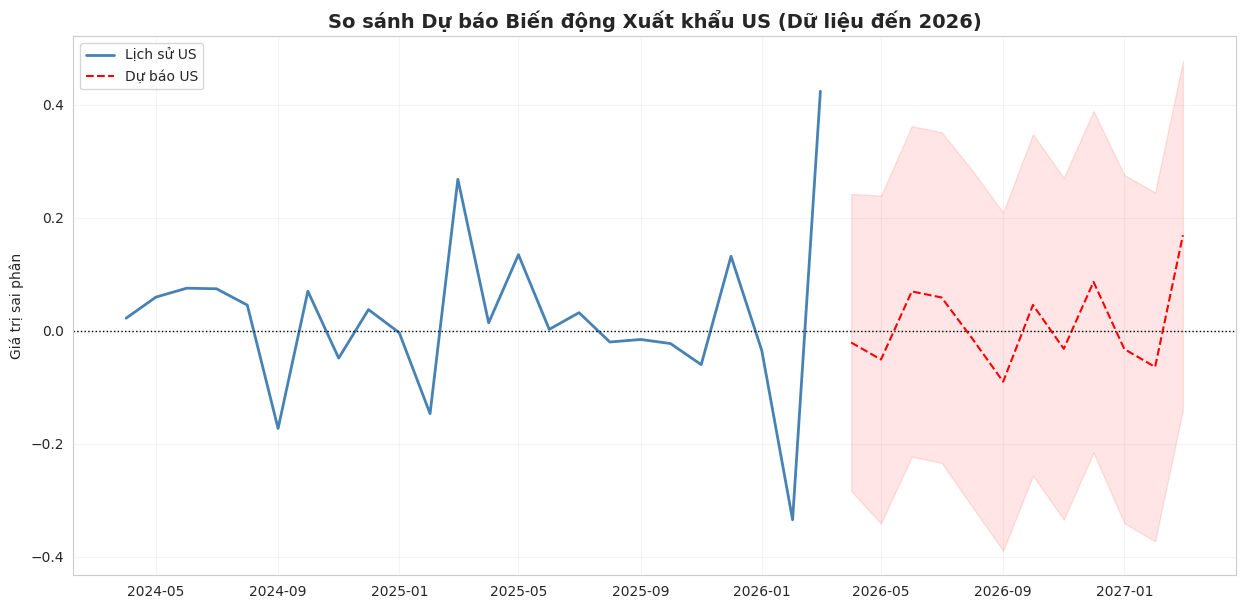

In [ ]:
plt.figure(figsize=(15, 7))

# Vẽ Export Mỹ
plt.plot(s_us_final.index[-24:], s_us_final.values[-24:], label='Lịch sử US', color='steelblue', lw=2)
plt.plot(fc_us_final.index, fc_us_final.values, label='Dự báo US', color='red', ls='--')
plt.fill_between(fc_us_final.index, ci_us_final.iloc[:, 0], ci_us_final.iloc[:, 1], color='red', alpha=0.1)

plt.axhline(0, color='black', lw=1, ls=':')
plt.title("So sánh Dự báo Biến động Xuất khẩu US (Dữ liệu đến 2026)", fontsize=14, fontweight='bold')
plt.ylabel("Giá trị sai phân")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


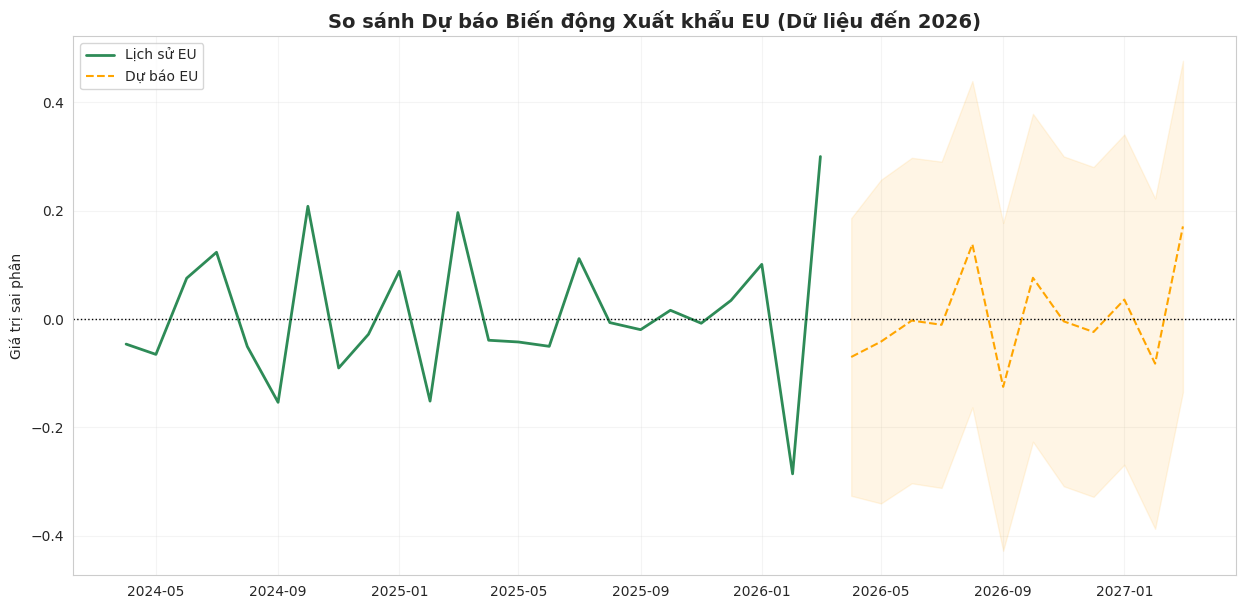

In [ ]:
plt.figure(figsize=(15, 7))

# Vẽ Export EU
plt.plot(s_eu_final.index[-24:], s_eu_final.values[-24:], label='Lịch sử EU', color='seagreen', lw=2)
plt.plot(fc_eu_final.index, fc_eu_final.values, label='Dự báo EU', color='orange', ls='--')
plt.fill_between(fc_eu_final.index, ci_eu_final.iloc[:, 0], ci_eu_final.iloc[:, 1], color='orange', alpha=0.1)

plt.axhline(0, color='black', lw=1, ls=':')
plt.title("So sánh Dự báo Biến động Xuất khẩu EU (Dữ liệu đến 2026)", fontsize=14, fontweight='bold')
plt.ylabel("Giá trị sai phân")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()


#### Phân tích kết quả dự báo ARIMA

Biểu đồ cho thấy mô hình ARIMA được sử dụng để dự báo biến động xuất khẩu của Việt Nam sang thị trường Mỹ và EU trong giai đoạn tiếp theo sau năm 2026.

Kết quả dự báo cho thấy cả hai thị trường đều có xu hướng biến động mạnh trong ngắn hạn. Đối với thị trường Mỹ, giá trị dự báo dao động lớn hơn và biên độ khoảng tin cậy khá rộng, phản ánh mức độ biến động và tính không chắc chắn cao của chuỗi xuất khẩu sang Mỹ. Trong một số giai đoạn, dự báo xuất hiện các mức giảm mạnh trước khi phục hồi trở lại.

Trong khi đó, thị trường EU có mức biến động ổn định hơn so với Mỹ. Giá trị dự báo dao động quanh mức trung bình với biên độ thay đổi nhỏ hơn và khoảng tin cậy hẹp hơn, cho thấy mức độ biến động thấp hơn.

Ngoài ra, khoảng tin cậy dự báo của cả hai mô hình đều mở rộng theo thời gian, cho thấy độ bất định của dự báo tăng lên ở các giai đoạn xa hơn trong tương lai. Điều này là đặc điểm phổ biến của các mô hình dự báo chuỗi thời gian như ARIMA.

## Thông điệp chính

> Xuất khẩu Việt Nam sang Mỹ và EU chịu ảnh hưởng rõ rệt từ sức cầu tiêu dùng quốc tế, nhưng tác động này có độ trễ, thay đổi theo từng giai đoạn và bị điều chỉnh bởi tỷ giá cũng như các cú sốc kinh tế. Vì vậy, để hiểu xuất khẩu Việt Nam, cần nhìn nó như một chuỗi phản ứng động giữa thị trường tiêu dùng toàn cầu, điều kiện tiền tệ và năng lực thích ứng của chuỗi cung ứng Việt Nam.